# NB09 — Mechanistic Flux Validation with MICOM

## The Holy Trinity of Producer Evidence
| Leg | Tool | Question answered |
|---|---|---|
| Statistical | SHAP (NB03) | Which species *correlates* with metabolite abundance in patients? |
| Genomic | GutSMASH (NB06) | Which species *encodes* the biosynthetic gene cluster? |
| **Mechanistic** | **MICOM (NB09)** | **Which species *actually secretes* the metabolite under gut conditions?** |

## Pipeline
```
Species relative abundances (YACHIDA — ALL stages: Healthy, Early_CRC, Advanced_CRC)
  └─ MICOM build()    — community FBA models from AGORA103 database
       └─ tradeoff=0.5 (hardcoded MICOM default; QP optimization requires CPLEX/Gurobi)
            └─ grow() — simulate growth on Western Diet
                 └─ exchanges — metabolite excretion fluxes per species (all metabolites)
                      └─ cross-reference with SHAP producers (NB03) — any metabolite
```

## Requirements
```
pip install micom
```
Download before running:
- **AGORA database:** `agora103_species.qza` from https://zenodo.org/record/7800476
- **Western Diet:** `western_diet_gut.csv` from https://github.com/micom-dev/micom/tree/main/data
- Placed both in `Data/micom/`

In [2]:
import sys, warnings, pickle, re
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path(".").resolve()))

from utils import (
    INTER_DIR, TABLE_DIR, FIG_DIR, DATA_DIR,
    DATASET_PRIMARY,
    annotate_pathway,
    load_pickle,
)

try:
    import micom
    from micom.workflows import build, grow  # tradeoff not used: hardcoded at 0.5
    print(f"micom {micom.__version__} loaded")
except ImportError:
    raise ImportError(
        "micom is required for this notebook.\n"
        "Install with: pip install micom"
    )

# ── Paths ──────────────────────────────────────────────
MICOM_DIR  = DATA_DIR / "micom"
AGORA_DB   = MICOM_DIR / "agora103_species.qza"
DIET_FILE  = MICOM_DIR / "western_diet_gut.csv"
MODELS_DIR = MICOM_DIR / "models"

# GROWTH_DIR and TRADEOFF_DIR removed: outputs written directly to MICOM_DIR
for d in [MICOM_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Preflight checks
missing = []
if not AGORA_DB.exists():  missing.append(str(AGORA_DB))
if not DIET_FILE.exists(): missing.append(str(DIET_FILE))
if missing:
    print("WARNING — missing required files:")
    for m in missing:
        print(f"  {m}")
    print("Download instructions in notebook header.")
else:
    print("All required files present. Ready to run MICOM.")


micom 0.39.0 loaded
All required files present. Ready to run MICOM.


## Step 1 — Load species relative abundances

In [3]:
pkl     = load_pickle(INTER_DIR / "preprocessed_data.pkl")
meta    = pkl["harmonized_meta"][DATASET_PRIMARY]

# MICOM requires relative (not CLR) abundances.
data_raw_ds = pkl.get("data_raw", {}).get(DATASET_PRIMARY, {})
spe_raw = data_raw_ds.get("species")
if spe_raw is None or (hasattr(spe_raw, "empty") and spe_raw.empty):
    spe_raw = pkl["species_filtered"][DATASET_PRIMARY]
    print("Using species_filtered (no data_raw[species] key found)")

# Include ALL stages (Healthy, Early_CRC, Advanced_CRC) for stage-stratified analysis
spe_all = spe_raw.copy()
print(f"All samples: {len(spe_all)}")
print(f"Stage breakdown:\n{meta['Stage.3Group'].value_counts().to_string()}")
print(f"Species in abundance table: {spe_all.shape[1]}")

# Renormalise each sample to sum = 1 (relative abundance)
spe_all = spe_all.div(spe_all.sum(axis=1), axis=0).fillna(0)

# Keep spe_adv alias — used by the AWRP fallback cell (bf72fe11)
adv_idx = meta[meta["Stage.3Group"] == "Advanced_CRC"].index
spe_adv = spe_all.loc[spe_all.index.isin(adv_idx)]

# ── Species name normalisation ─────────────────────────────────────────────
def extract_binomial(gtdb_str: str) -> tuple:
    """Return (genus, epithet) from a GTDB full taxonomy string.
    Returns (None, None) for GTDB genome-bin IDs with no real species name.
    """
    parts = str(gtdb_str).split(";")
    for p in reversed(parts):
        p = p.strip()
        if p.startswith("s__"):
            name = p[3:].strip()
            tokens = name.split()
            if len(tokens) < 2:
                return (None, None)
            genus, epithet = tokens[0], tokens[1]
            # Strip GTDB polyphyletic disambiguation suffixes from both genus and species
            genus   = re.sub(r"_[A-Z]+$", "", genus)
            epithet = re.sub(r"_[A-Z]+$", "", epithet)
            if not genus or not epithet:
                return (None, None)
            if not genus[0].isupper():
                return (None, None)
            if not epithet[0].islower():
                return (None, None)
            if re.match(r"^sp\d", epithet):
                return (None, None)
            return (genus, epithet)
    return (None, None)

tax_long = (
    spe_all                                              # ← all stages, was spe_adv
    .reset_index()
    .rename(columns={spe_all.index.name or "index": "sample_id"})
    .melt(id_vars="sample_id", var_name="_raw_species", value_name="abundance")
)
tax_long = tax_long[tax_long["abundance"] > 1e-5].copy()
tax_long["sample_id"] = tax_long["sample_id"].astype(str)

parsed = tax_long["_raw_species"].apply(extract_binomial)
tax_long["genus"]   = parsed.apply(lambda x: x[0])
tax_long["species"] = parsed.apply(lambda x: x[1])

n_before = len(tax_long)
tax_long = tax_long.dropna(subset=["genus", "species"]).drop(columns=["_raw_species"])
n_after = len(tax_long)
print(f"Dropped {n_before - n_after:,} rows with unresolvable GTDB genome-bin IDs")

# Deduplicate: multiple GTDB strains map to same NCBI species after suffix stripping
# Sum their abundances so each (sample_id, genus, species) appears once per sample
n_pre_dedup = len(tax_long)
tax_long = (
    tax_long.groupby(["sample_id", "genus", "species"], as_index=False)
    ["abundance"].sum()
)
print(f"Deduplicated {n_pre_dedup - len(tax_long):,} duplicate strain rows (summed abundance)")

# Add stage label to each row (for downstream stage-stratified aggregation)
_stage_map = {str(k): v for k, v in meta["Stage.3Group"].to_dict().items()}
tax_long["stage"] = tax_long["sample_id"].map(_stage_map)
print(f"Stage distribution in tax_long:\n{tax_long['stage'].value_counts().to_string()}")

n_samples = tax_long["sample_id"].nunique()
n_species = tax_long[["genus", "species"]].drop_duplicates().shape[0]
ex = tax_long[["genus", "species"]].drop_duplicates().head(3)
print(f"\nTaxonomy table: {len(tax_long):,} rows ({n_samples} samples, {n_species} unique genus+species pairs)")
print(f"Example entries:\n{ex.to_string(index=False)}")

Loaded: E:\D.Ani\Academic\KI\Results\intermediate\preprocessed_data.pkl
All samples: 347
Stage breakdown:
Stage.3Group
Advanced_CRC    163
Healthy         127
Early_CRC        57
Species in abundance table: 57702
Dropped 347,623 rows with unresolvable GTDB genome-bin IDs
Deduplicated 25,892 duplicate strain rows (summed abundance)
Stage distribution in tax_long:
stage
Advanced_CRC    74012
Healthy         54797
Early_CRC       25944

Taxonomy table: 154,753 rows (347 samples, 3511 unique genus+species pairs)
Example entries:
          genus      species
  Acetatifactor intestinalis
Acidaminococcus    intestini
  Acinetobacter  idrijaensis


## Step 2 — Build community FBA models from AGORA103 database

In [4]:
manifest_path = MICOM_DIR / "manifest.csv"

# Expected sample count from tax_long
expected_samples = tax_long["sample_id"].nunique()

if manifest_path.exists():
    manifest = pd.read_csv(manifest_path)
    if len(manifest) == 0:
        print("Cached manifest is empty (likely from a failed build). Deleting and rebuilding ...")
        manifest_path.unlink()
        manifest = None
    elif len(manifest) < expected_samples:
        print(f"Manifest has {len(manifest)} rows but {expected_samples} samples expected.")
        print("Deleting manifest to trigger rebuild (existing model pickles preserved) ...")
        manifest_path.unlink()
        manifest = None
    else:
        print(f"Loading existing manifest ({len(manifest)} samples) ...")
else:
    manifest = None

if manifest is None:
    existing_pickles = len(list(MODELS_DIR.glob("*.pickle")))
    print(f"Building community models — {existing_pickles} existing pickles will be reused ...")
    # Pre-extract AGORA .qza once: Community() re-unzips the 50 MB file per sample
    # otherwise, adding ~30-60 s per model. Directory path bypasses that entirely.
    AGORA_EXTRACTED = MICOM_DIR / "agora_extracted"
    if AGORA_EXTRACTED.exists() and any(AGORA_EXTRACTED.rglob("manifest.csv")):
        _agora_manifests = list(AGORA_EXTRACTED.rglob("manifest.csv"))
        AGORA_MODEL_DIR = str(Path(_agora_manifests[0]).parent)
        print(f"Reusing pre-extracted AGORA at {AGORA_MODEL_DIR}")
    else:
        from micom.qiime_formats import load_qiime_model_db
        AGORA_EXTRACTED.mkdir(parents=True, exist_ok=True)
        print("Pre-extracting AGORA103 .qza (one-time, ~30 s) ...")
        _manifest_ea = load_qiime_model_db(str(AGORA_DB), str(AGORA_EXTRACTED))
        AGORA_MODEL_DIR = str(Path(_manifest_ea["file"].iloc[0]).parent)
        print(f"AGORA pre-extracted to {AGORA_MODEL_DIR}")
    manifest = build(
        tax_long,
        out_folder=str(MODELS_DIR),
        model_db=AGORA_MODEL_DIR,   # pre-extracted dir: no per-sample .qza unzip
        cutoff=1e-3,    # 0.1% threshold: limits community size after genus/species fix
        threads=4,      # dedup fix prevents duplicate-species worker crashes
    )
    manifest.to_csv(manifest_path, index=False)

print(f"Models built: {len(manifest)}")

# C9 FIX: E9 AGORA103 coverage report for Methods
# Direct model = exact species match; genus-level = best available approximation
_cov_col2 = next(
    (col for col in ("found_fraction", "found_abundance_fraction", "coverage")
     if col in manifest.columns), None
)
if _cov_col2:
    _direct  = (manifest[_cov_col2] >= 0.90).sum()
    _bridged = (manifest[_cov_col2] < 0.90).sum()
    print(f"C9 — E9 AGORA103 coverage: {_direct} samples with ≥90% direct species models")
    print(f"                          {_bridged} samples via partial/genus-level coverage")
    print(f"  Median coverage: {manifest[_cov_col2].median():.1%}")
else:
    print("C9 — E9 AGORA103 coverage: run_type logged in flux_summary (coverage col not found)")
if len(manifest) == 0:
    raise RuntimeError(
        "build() returned an empty manifest — no species matched the AGORA database.\n"
        "Run the diagnostic cell (Cell 6) to check species name overlap."
    )

# MICOM 0.39 uses 'found_abundance_fraction'; older versions use 'coverage'
_cov_col = next(
    (c for c in ("coverage", "found_abundance_fraction") if c in manifest.columns),
    None,
)
if _cov_col:
    print(f"Median AGORA abundance coverage: {manifest[_cov_col].median():.1%}")
    low_cov = manifest[manifest[_cov_col] < 0.50]
    if len(low_cov):
        print(f"WARNING: {len(low_cov)} samples have <50% AGORA abundance coverage")
for _stat in ("found_taxa", "total_taxa", "found_fraction"):
    if _stat in manifest.columns:
        print(f"  Median {_stat}: {manifest[_stat].median():.3g}")
print(manifest.head().to_string(index=False))

Loading existing manifest (347 samples) ...
Models built: 347
C9 — E9 AGORA103 coverage: 0 samples with ≥90% direct species models
                          347 samples via partial/genus-level coverage
  Median coverage: 40.6%
Median AGORA abundance coverage: 42.6%
  Median found_taxa: 29
  Median total_taxa: 72
  Median found_fraction: 0.406
 sample_id        stage         file  found_taxa  total_taxa  found_fraction  found_abundance_fraction
     10021 Advanced_CRC 10021.pickle        26.0        67.0        0.388060                  0.340662
     10023      Healthy 10023.pickle        25.0        65.0        0.384615                  0.219942
     10025      Healthy 10025.pickle        31.0        71.0        0.436620                  0.455875
     10029      Healthy 10029.pickle        33.0        73.0        0.452055                  0.406290
     10031      Healthy 10031.pickle        41.0        83.0        0.493976                  0.438642


In [5]:
# Diagnostic: check genus+species overlap with AGORA103 database
# Run this if build() reports low coverage — it shows exactly which species matched.
import io
from zipfile import ZipFile

print("=== AGORA Species Name Overlap Diagnostic ===")
user_pairs = set(zip(tax_long["genus"], tax_long["species"]))
print(f"Unique (genus, species) pairs in taxonomy table: {len(user_pairs)}")
print("Sample entries:")
for g, e in list(user_pairs)[:5]:
    print(f"  genus={g!r:30s}  species={e!r}")

if AGORA_DB.exists():
    with ZipFile(str(AGORA_DB), "r") as z:
        manifest_files = [f for f in z.namelist() if f.endswith("manifest.csv")]
        if manifest_files:
            with z.open(manifest_files[0]) as f:
                agora_mdf = pd.read_csv(f)
            agora_pairs = set(zip(agora_mdf["genus"], agora_mdf["species"]))
            overlap = user_pairs & agora_pairs
            pct = 100 * len(overlap) / max(1, len(agora_pairs))
            print(f"\nAGORA103 species: {len(agora_pairs)}")
            print(f"Matched: {len(overlap)} / {len(agora_pairs)} AGORA species ({pct:.1f}%)")
            if overlap:
                print("\nMatched examples (first 10):")
                for g, e in sorted(overlap)[:10]:
                    print(f"  {g} {e}")
            else:
                print("WARNING: Zero overlap! genus+species columns must match AGORA manifest exactly.")
                print("AGORA manifest sample (genus, species):")
                print(agora_mdf[["genus","species"]].head(5).to_string(index=False))
        else:
            print(f"No manifest.csv found inside {AGORA_DB.name}")
else:
    print(f"AGORA DB not found at {AGORA_DB}")
    print("Download from https://zenodo.org/record/7800476 and place in Data/micom/")


=== AGORA Species Name Overlap Diagnostic ===
Unique (genus, species) pairs in taxonomy table: 3511
Sample entries:
  genus='Flaviaesturariibacter'         species='aridisoli'
  genus='Fournierella'                  species='excrementigallinarum'
  genus='Fusicatenibacter'              species='intestinigallinarum'
  genus='Ligilactobacillus'             species='saerimneri'
  genus='Cryptoclostridium'             species='obscurum'

AGORA103 species: 587
Matched: 330 / 587 AGORA species (56.2%)

Matched examples (first 10):
  Abiotrophia defectiva
  Acidaminococcus intestini
  Acinetobacter baumannii
  Acinetobacter junii
  Acinetobacter lwoffii
  Actinomyces graevenitzii
  Actinomyces naeslundii
  Actinomyces urogenitalis
  Actinomyces viscosus
  Adlercreutzia equolifaciens


## Step 3 — Find optimal community tradeoff parameter

In [6]:
if len(manifest) == 0:
    raise RuntimeError("Manifest is empty — fix species name matching in Cell 3 first.")

tradeoff_path = MICOM_DIR / "tradeoff_results.csv"

# Load Western Diet medium
medium = pd.read_csv(DIET_FILE)
if "reaction" not in medium.columns or "flux" not in medium.columns:
    raise ValueError(
        f"western_diet_gut.csv must have reaction and flux columns; got: {list(medium.columns)}"
    )
print(f"Western Diet medium: {len(medium)} reactions")
n_converted = medium["reaction"].str.endswith("_e").sum()
medium["reaction"] = medium["reaction"].str.replace(r"_e$", "_m", regex=True)
if n_converted:
    print(f"Converted {n_converted} reaction IDs from _e → _m format")
else:
    print("Reaction IDs already in _m format (western_diet_gut.csv v2+)")

# ── Tradeoff parameter ─────────────────────────────────────────────────────
# The cooperative tradeoff step requires a QP-capable solver (CPLEX/Gurobi).
# community.py patched to prefer osqp > coinor_cbc > hybrid > glpk.
# MICOM default tradeoff: 0.5 for metagenomics, 0.3 for 16S.
# 0.5 used here as data is shotgun metagenomics (Yachida et al., 2019).
optimal_tradeoff = 0.5
print(f"Optimal tradeoff parameter (hardcoded): {optimal_tradeoff:.2f}")
print("(MICOM default for metagenomics: 0.5 — avoids unsolvable QP with GLPK)")

# Write a marker CSV so this cell never re-runs the tradeoff computation.
if not tradeoff_path.exists():
    pd.DataFrame({"tradeoff": [optimal_tradeoff], "note": ["hardcoded"]}).to_csv(
        tradeoff_path, index=False
    )
    print(f"Saved marker: {tradeoff_path.name}")

Western Diet medium: 170 reactions
Converted 170 reaction IDs from _e → _m format
Optimal tradeoff parameter (hardcoded): 0.50
(MICOM default for metagenomics: 0.5 — avoids unsolvable QP with GLPK)


## Step 4 — Simulate community growth on Western Diet

In [7]:
import types as _types

if len(manifest) == 0:
    raise RuntimeError("Manifest is empty — fix species name matching in Step 1 first.")

growth_all_path = MICOM_DIR / "growth_results_all.pkl"
growth_adv_path = MICOM_DIR / "growth_results.pkl"    # legacy: Advanced_CRC only

if growth_all_path.exists():
    print("Loading existing all-stage growth results ...")
    _exchanges_df = pd.read_pickle(growth_all_path)
    growth_results = _types.SimpleNamespace(exchanges=_exchanges_df)
else:
    # ── Reuse existing Advanced_CRC results ───────────────────────────────────────
    adv_exchanges = None
    done_ids = set()
    if growth_adv_path.exists():
        with open(growth_adv_path, "rb") as f:
            gr_adv = pickle.load(f)
        adv_exchanges = gr_adv.exchanges
        done_ids = set(adv_exchanges["sample_id"].astype(str))
        print(f"Loaded Advanced_CRC exchanges: {len(adv_exchanges):,} rows, {len(done_ids)} samples")

    # ── Identify samples still needing grow() ────────────────────────────────────
    all_ids = set(manifest["sample_id"].astype(str))
    missing_ids = all_ids - done_ids
    print(f"Samples needing grow(): {len(missing_ids)} (Healthy + Early_CRC)")

    new_exchanges = None
    _batch_complete = False
    if missing_ids:
        manifest_new = manifest[manifest["sample_id"].astype(str).isin(missing_ids)].copy()

        smoke_path = MICOM_DIR / "growth_smoke_new.pkl"
        if not smoke_path.exists():
            # ── Smoke test: 3 new samples before the full batch ───────────────────
            print("Smoke test: running grow() on 3 new samples (Healthy/Early_CRC) ...")
            gr_smoke = grow(
                manifest_new.sample(n=min(3, len(manifest_new)), random_state=42),
                model_folder=str(MODELS_DIR),
                medium=medium,
                tradeoff=optimal_tradeoff,
                threads=1,
                strategy="none",
                presolve=True,
            )
            with open(smoke_path, "wb") as f:
                pickle.dump(gr_smoke, f)
            print(f"Smoke test PASSED — {len(gr_smoke.exchanges)} exchange rows.")
            print("Next: delete Data/micom/growth_smoke_new.pkl then re-run this cell for full batch.")
            new_exchanges = gr_smoke.exchanges
            _batch_complete = False    # smoke only — do NOT save merged results yet
        else:
            # ── Full batch for remaining samples ─────────────────────────────────
            print(f"Running grow() for {len(manifest_new)} samples (Healthy + Early_CRC) ...")
            gr_new = grow(
                manifest_new,
                model_folder=str(MODELS_DIR),
                medium=medium,
                tradeoff=optimal_tradeoff,
                threads=1,
                strategy="none",
                presolve=True,
            )
            new_exchanges = gr_new.exchanges
            _batch_complete = True

    # ── Merge ─────────────────────────────────────────────────────────────────────
    parts = [p for p in [adv_exchanges, new_exchanges] if p is not None]
    combined = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    growth_results = _types.SimpleNamespace(exchanges=combined)

    # ── Save (full batch only — not during smoke test) ────────────────────────────
    if _batch_complete:
        combined.to_pickle(growth_all_path)
        print("Saved growth_results_all.pkl")

print("Growth results ready.")
print(f"Exchanges DataFrame: {growth_results.exchanges.shape}")
print(f"Columns: {list(growth_results.exchanges.columns)}")

Loading existing all-stage growth results ...
Growth results ready.
Exchanges DataFrame: (702311, 8)
Columns: ['taxon', 'sample_id', 'tolerance', 'reaction', 'flux', 'abundance', 'metabolite', 'direction']


In [8]:
# ── Equal-abundance control run (circularity fix) ─────────────────────────────
# Circularity problem: abundance-weighted grow() reuses the SAME signal as
# SHAP (both depend on YACHIDA species relative abundances). This means MICOM
# appears to 'confirm' SHAP not because of FBA mechanics but because they share
# the same input data.
#
# Fix: run grow() a second time with EQUAL abundances (1/N per species per sample)
# to obtain the pure mechanistic flux signal, independent of patient-specific
# abundance data. Metabolites excreted only in the abundance-weighted run (not
# the equal-abundance run) may reflect abundance correlations rather than
# mechanistic capacity.
#
# Label figures distinguishing:
#   'abundance_weighted' — actual patient abundances (current run)
#   'equal_abundance'    — 1/N per species (mechanistic capacity baseline)

import types as _types

growth_equalabund_path = MICOM_DIR / "growth_results_equalabund.pkl"

if growth_equalabund_path.exists():
    print("Loading existing equal-abundance growth results ...")
    _ea_df = pd.read_pickle(growth_equalabund_path)
    growth_equalabund = _types.SimpleNamespace(exchanges=_ea_df)
else:
    print("Building equal-abundance taxonomy table ...")
    # Start from the same tax_long used for abundance-weighted manifest,
    # but set all relative_abundance values to 1/N_species_in_that_sample.
    tax_ea = tax_long.copy()
    # Count species per sample
    n_per_sample = tax_ea.groupby("sample_id")["abundance"].transform("count")
    tax_ea["abundance"] = 1.0 / n_per_sample

    # Write a separate manifest for equal-abundance communities.
    # build() can reuse the same MODELS_DIR .pickle files — no re-solve needed.
    manifest_ea_path = MICOM_DIR / "manifest_equalabund.csv"
    if manifest_ea_path.exists():
        manifest_ea = pd.read_csv(manifest_ea_path)
        print(f"Loaded existing equal-abundance manifest ({len(manifest_ea)} samples)")
    else:
        print("Building equal-abundance manifest (model .pickle files reused) ...")
        manifest_ea = build(
            tax_ea,
            out_folder=str(MODELS_DIR),
            model_db=str(AGORA_DB),
            cutoff=0.0,      # do not filter by abundance — all species present equally
            threads=4,
        )
        manifest_ea.to_csv(manifest_ea_path, index=False)
        print(f"Equal-abundance manifest saved ({len(manifest_ea)} samples)")

    if len(manifest_ea) == 0:
        print("WARNING: equal-abundance manifest is empty — skipping equal-abundance run.")
        growth_equalabund = _types.SimpleNamespace(exchanges=pd.DataFrame())
    else:
        ea_smoke_path = MICOM_DIR / "growth_equalabund_smoke.pkl"
        if not ea_smoke_path.exists():
            print("Smoke test: grow() on 3 equal-abundance samples ...")
            gr_ea_smoke = grow(
                manifest_ea.sample(n=min(3, len(manifest_ea)), random_state=99),
                model_folder=str(MODELS_DIR),
                medium=medium,
                tradeoff=optimal_tradeoff,
                threads=1,
                strategy="none",
                presolve=True,
            )
            with open(ea_smoke_path, "wb") as f:
                pickle.dump(gr_ea_smoke, f)
            print(f"Equal-abundance smoke test PASSED — {len(gr_ea_smoke.exchanges)} exchange rows.")
            print("Delete Data/micom/growth_equalabund_smoke.pkl then re-run for full batch.")
            growth_equalabund = _types.SimpleNamespace(exchanges=gr_ea_smoke.exchanges)
        else:
            print(f"Running full equal-abundance grow() for {len(manifest_ea)} samples ...")
            gr_ea = grow(
                manifest_ea,
                model_folder=str(MODELS_DIR),
                medium=medium,
                tradeoff=optimal_tradeoff,
                threads=1,
                strategy="none",
                presolve=True,
            )
            gr_ea.exchanges.to_pickle(growth_equalabund_path)
            print(f"Saved growth_results_equalabund.pkl")
            growth_equalabund = gr_ea

print(f"Equal-abundance exchanges: {growth_equalabund.exchanges.shape}")

# ── Tag both DataFrames with run_type ─────────────────────────────────────────
# Attach run_type column so downstream cells can filter or compare.
if not growth_results.exchanges.empty:
    growth_results.exchanges["run_type"] = "abundance_weighted"
if not growth_equalabund.exchanges.empty:
    growth_equalabund.exchanges["run_type"] = "equal_abundance"

# Combined frame for comparisons (optional)
if not growth_equalabund.exchanges.empty and not growth_results.exchanges.empty:
    growth_both = pd.concat(
        [growth_results.exchanges, growth_equalabund.exchanges], ignore_index=True
    )
    print(f"Combined both runs: {len(growth_both):,} exchange rows")
    print(growth_both.groupby('run_type').size().to_string())
else:
    growth_both = growth_results.exchanges.copy()
    print("Equal-abundance run unavailable — growth_both == abundance_weighted only.")

Loading existing equal-abundance growth results ...
Equal-abundance exchanges: (464895, 8)
Combined both runs: 1,167,206 exchange rows
run_type
abundance_weighted    702311
equal_abundance       464895


In [9]:
# ── Track B fallback: Abundance-Weighted Reaction Presence (AWRP) ───────────
# Use this cell INSTEAD OF the grow() cell if CBC/OSQP still hangs.
#
# Concept: for each species, extract which metabolites it CAN exchange from AGORA103
# (genomic capacity), then weight by relative abundance per sample.
# This is equivalent to the MIMOSA2 approach and is a validated proxy for
# microbial metabolite production potential in the literature.
#
# INTERPRETATION:
#   "flux" = species relative abundance (NOT an FBA-derived flux value).
#   "direction" = "potential" (AWRP cannot determine import vs export — no FBA).
#   This estimates metabolic CAPACITY, not actual secretion rate under Western Diet.
#   Label figures as "Abundance-Weighted Production Potential" not "Flux".
#
# Activate: set USE_AWRP = True
# Requires: Cell 3 must have been run (extract_binomial defined there)

USE_AWRP = False   # <-- flip to True if grow() still hangs after solver patch

if USE_AWRP:
    import zipfile, io, types as _types
    from cobra.io import load_json_model, read_sbml_model

    print("Running AWRP (solver-free metabolic potential scoring) ...")
    agora_cache = {}   # "genus_species" -> sorted list of met_m IDs

    with zipfile.ZipFile(str(AGORA_DB)) as zf:
        model_files = [f for f in zf.namelist()
                       if f.endswith(".json") or f.endswith(".xml")]
        print(f"AGORA archive: {len(model_files)} model files")
        for fname in model_files:
            with zf.open(fname) as fh:
                try:
                    # Dispatch on format: JSON vs SBML/XML
                    if fname.endswith(".json"):
                        m = load_json_model(io.TextIOWrapper(fh, encoding="utf-8"))
                    else:
                        m = read_sbml_model(fh)
                    key = m.id.lower()
                    # Anchored regex strips _e suffix only at end-of-string
                    # to avoid corrupting IDs with _e mid-string (e.g. ser__L_e)
                    agora_cache[key] = sorted({
                        re.sub(r"_e$", "_m", r.id.replace("EX_", ""))
                        for r in m.exchanges
                    })
                except Exception:
                    pass

    print(f"Loaded {len(agora_cache)} AGORA species models")

    # ── Memory-efficient build: one small DataFrame per species (not one dict per row) ──
    # Avoids accumulating millions of Python dicts before pd.DataFrame() is called.
    chunk_dfs = []
    for sample_id, row in spe_all.iterrows():
        sample_id_str = str(sample_id)
        for col, abund in row.items():
            if abund < 1e-5:
                continue
            genus, epithet = extract_binomial(col)
            if not genus or not epithet:
                continue
            key = f"{genus}_{epithet}".lower()
            if key not in agora_cache:
                continue
            rxns = agora_cache[key]
            chunk_dfs.append(pd.DataFrame({
                "sample_id":  sample_id_str,
                "taxon":      f"{genus} {epithet}",
                "reaction":   rxns,
                "flux":       float(abund),     # abundance proxy, NOT FBA flux
                "metabolite": rxns,             # already stripped to met_m format
                "direction":  "potential",      # AWRP has no directional FBA info
            }))

    if chunk_dfs:
        awrp_exchanges = pd.concat(chunk_dfs, ignore_index=True)
        del chunk_dfs   # release intermediate memory
    else:
        awrp_exchanges = pd.DataFrame(
            columns=["sample_id", "taxon", "reaction", "flux", "metabolite", "direction"]
        )

    print(f"AWRP exchange table: {awrp_exchanges.shape}")
    n_mets = awrp_exchanges["metabolite"].nunique()
    print(f"Unique metabolites represented: {n_mets}")

    # Wrap in SimpleNamespace mirroring GrowthResults — downstream cells (Steps 5-7) unchanged.
    # Use SimpleNamespace (not namedtuple) so the object is picklable regardless of kernel state.
    growth_results = _types.SimpleNamespace(exchanges=awrp_exchanges)
    awrp_exchanges.to_pickle(MICOM_DIR / "growth_results_awrp.pkl")

    print("AWRP complete. growth_results ready for Steps 5-7.")
    print("NOTE: flux values are abundance proxies. Label figures as \"Production Potential\".")
else:
    print("AWRP disabled (USE_AWRP=False). Using grow() results from the cell above.")
    print("Flip USE_AWRP=True if the grow() cell hangs.")

AWRP disabled (USE_AWRP=False). Using grow() results from the cell above.
Flip USE_AWRP=True if the grow() cell hangs.


## Step 5 — Extract and summarise all metabolite excretion fluxes

Maps AGORA/BiGG exchange IDs to human-readable metabolite names, annotates pathways,
and produces a ranked `flux_summary` table covering *all* metabolites (not just polyamines).
Polyamines are available as a filtered subset via `flux_summary[flux_summary.pathway == 'Polyamine']`.

### MICOM Flux Magnitude Caveat

> **T2.11 — Publication disclosure:**
> MICOM was run with `strategy='none'` (no cooperative tradeoff optimisation). This can produce **physiologically implausible flux magnitudes** (up to 98+ mmol/gDW/h for some excretion reactions). The **direction** of flux (positive = net excretion = production) is reliable and forms the basis of E9 evidence scoring. Magnitude should not be interpreted literally.

> **Trinity pair count note:** After T1.11 correction (genus DA enrichment filter), trinity pair counts will update on NB09 re-run. Previous values (65 genus_confirmed rows) included depleted co-genus species. Report corrected counts after re-run.

> **Recommended text:** *'MICOM community flux simulations (equal-abundance control) were used to identify species with positive net excretion flux for target polyamines. Flux direction is used as binary evidence (E9); absolute magnitudes reflect the parsimonious FBA solution under strategy="none" and are not calibrated to in vivo concentrations.'*

In [10]:
fluxes = growth_results.exchanges.copy()

# Positive flux = net excretion (production into gut lumen)
prod_fluxes = fluxes[fluxes["flux"] > 0].copy()

# Flag unconstrained exchange fluxes (default COBRA upper bounds: 1000 or 100)
UNCONSTRAINED_THRESHOLD = 80.0
n_unconstrained = (prod_fluxes["flux"] >= UNCONSTRAINED_THRESHOLD).sum()
if n_unconstrained:
    print(f"WARNING: {n_unconstrained} exchange rows at default COBRA bounds "
          f"(flux >= {UNCONSTRAINED_THRESHOLD}) — likely unconstrained. Filtered out.")
    prod_fluxes = prod_fluxes[prod_fluxes["flux"] < UNCONSTRAINED_THRESHOLD].copy()

# ── Add stage label via sample_id → Stage.3Group join ─────────────────────────
_stage_map2 = {str(k): v for k, v in meta["Stage.3Group"].to_dict().items()}
prod_fluxes["stage"] = prod_fluxes["sample_id"].astype(str).map(_stage_map2).fillna("Unknown")
print(f"Stage distribution in prod_fluxes:\n{prod_fluxes['stage'].value_counts().to_string()}")

# ── Strip AGORA/BiGG compartment suffixes ─────────────────────────────────────
_COMPARTMENT_RE = re.compile(r'(?:_[em]|\[e\]|\[m\]|\(e\)|\(m\))$')

def _strip_compartment(met_id):
    return _COMPARTMENT_RE.sub("", str(met_id))

prod_fluxes["met_base"] = prod_fluxes["metabolite"].apply(_strip_compartment)

# ── BiGG ID → human-readable name ─────────────────────────────────────────────
BIGG_NAMES = {
    "ac": "Acetate", "but": "Butyrate", "ppa": "Propionate",
    "for": "Formate", "succ": "Succinate", "fum": "Fumarate",
    "mal_L": "Malate", "lac_L": "Lactate", "lac_D": "D-Lactate",
    "akg": "Alpha-Ketoglutarate", "pyr": "Pyruvate", "cit": "Citrate",
    "oaa": "Oxaloacetate", "oxa": "Oxalate", "acac": "Acetoacetate",
    "acald": "Acetaldehyde", "etoh": "Ethanol",
    "hdca": "Palmitate", "ocdca": "Stearate", "ocdcea": "Oleate",
    "ddca": "Dodecanoate", "ttdca": "Tetradecanoate",
    "pac": "Phenylacetate", "hxa": "Hexanoate",
    "ptrc": "Putrescine", "spmd": "Spermidine", "spmi": "Spermine",
    "agmt": "Agmatine", "cadav": "Cadaverine",
    "orn": "Ornithine", "arg_L": "Arginine",
    "ala_L": "Alanine", "ala_D": "D-Alanine", "gly": "Glycine",
    "val_L": "Valine", "leu_L": "Leucine", "ile_L": "Isoleucine",
    "pro_L": "Proline", "phe_L": "Phenylalanine", "trp_L": "Tryptophan",
    "tyr_L": "Tyrosine", "ser_L": "Serine", "thr_L": "Threonine",
    "cys_L": "Cysteine", "met_L": "Methionine", "asn_L": "Asparagine",
    "asp_L": "Aspartate", "glu_L": "Glutamate", "gln_L": "Glutamine",
    "his_L": "Histidine", "lys_L": "Lysine",
    "gbbtn": "Gamma-Butyrobetaine", "crn": "Carnitine",
    "4abut": "GABA", "urea": "Urea",
    "indole": "Indole",
    "ade": "Adenine", "gua": "Guanine", "xan": "Xanthine",
    "hxan": "Hypoxanthine", "ura": "Uracil",
    "adn": "Adenosine", "gsn": "Guanosine", "uri": "Uridine",
    "ins": "Inosine", "cytd": "Cytidine",
    "amp": "AMP", "nmn": "NMN",
    "dad_2": "Deoxyadenosine", "dcyt": "Deoxycytidine",
    "dgsn": "Deoxyguanosine", "thymd": "Thymidine", "drib": "Deoxyribose",
    "ribflv": "Riboflavin", "fol": "Folate", "thm": "Thiamine",
    "nac": "Nicotinate", "ncam": "Nicotinamide",
    "pydx": "Pyridoxal", "pydxn": "Pyridoxine", "pydam": "Pyridoxamine",
    "pnto_R": "Pantothenate", "thf": "Tetrahydrofolate",
    "glc_D": "Glucose", "fru": "Fructose", "gal": "Galactose",
    "man": "Mannose", "xyl_D": "Xylose", "arab_D": "D-Arabinose",
    "arab_L": "L-Arabinose", "rmn": "Rhamnose", "fuc_L": "Fucose",
    "rib_D": "Ribose", "glcn": "Gluconate", "glcur": "Glucuronate",
    "galur": "Galacturonate", "lcts": "Lactose", "malt": "Maltose",
    "sucr": "Sucrose", "tre": "Trehalose", "melib": "Melibiose",
    "cellb": "Cellobiose",
    "h2": "Hydrogen", "co2": "CO2", "h2s": "Hydrogen Sulfide",
    "o2": "Oxygen", "nh4": "Ammonium", "no2": "Nitrite",
    "h": "Proton", "h2o": "Water",
    "pi": "Phosphate", "so4": "Sulfate",
    "k": "Potassium", "ca2": "Calcium", "mg2": "Magnesium",
    "fe2": "Iron(II)", "fe3": "Iron(III)", "mn2": "Manganese",
    "zn2": "Zinc", "cu2": "Copper", "cobalt2": "Cobalt",
    "cl": "Chloride",
    "tma": "Trimethylamine", "chol": "Choline",
    "cholate": "Cholate", "7dhcdchol": "7-Dehydrocholesterol",
    "pheme": "Heme", "sheme": "Siroheme",
    "glyc": "Glycerol", "glyc3p": "Glycerol-3-Phosphate",
    "glyclt": "Glycolate",
    "g6p": "Glucose-6-Phosphate", "mnl": "Mannitol",
    "gam": "Glucosamine", "acgam": "N-Acetylglucosamine",
    "acnam": "N-Acetylneuraminate", "acmana": "N-Acetylmannosamine",
    "bglc": "Beta-Glucoside", "cgly": "Cysteinylglycine",
    "gthrd": "Glutathione (reduced)", "gthox": "Glutathione (oxidized)",
    "chor": "Chorismate", "4hbz": "4-Hydroxybenzoate", "4abz": "4-Aminobenzoate",
    "actn_R": "R-Acetoin", "lald_L": "L-Lactaldehyde",
}

BIGG_TO_KEGG = {
    "ac": "C00033", "but": "C00246", "ppa": "C00163",
    "for": "C00058", "succ": "C00042", "fum": "C00122",
    "mal_L": "C00149", "lac_L": "C00186", "lac_D": "C00196",
    "akg": "C00026", "pyr": "C00022", "cit": "C00158",
    "oaa": "C00036", "acac": "C00164", "acald": "C00084", "etoh": "C00469",
    "hdca": "C00249", "ocdca": "C01571", "ocdcea": "C00712",
    "ddca": "C02679", "ttdca": "C06424",
    "pac": "C07086",
    "ptrc": "C00134", "spmd": "C00315", "spmi": "C00750",
    "agmt": "C00986", "cadav": "C01672",
    "orn": "C00077", "arg_L": "C00062",
    "ala_L": "C00041", "gly": "C00037", "val_L": "C00183",
    "leu_L": "C00123", "ile_L": "C00407", "pro_L": "C00148",
    "phe_L": "C00079", "trp_L": "C00078", "tyr_L": "C00082",
    "ser_L": "C00065", "thr_L": "C00188", "cys_L": "C00097",
    "met_L": "C00073", "asn_L": "C00152", "asp_L": "C00049",
    "glu_L": "C00025", "gln_L": "C00064", "his_L": "C00135",
    "lys_L": "C00047", "4abut": "C00334", "urea": "C00086",
    "ribflv": "C00255", "fol": "C00504", "thm": "C00378",
    "nac": "C00253", "ncam": "C00153",
    "pydxn": "C00314", "pydx": "C00250", "pydam": "C00534",
    "pnto_R": "C00864",
    "glc_D": "C00031", "fru": "C00095", "gal": "C00124",
    "man": "C00159", "xyl_D": "C00181", "rib_D": "C00121",
    "glcur": "C00191", "lcts": "C00243", "malt": "C00208",
    "sucr": "C00089",
    "ade": "C00147", "gua": "C00242", "xan": "C00385",
    "hxan": "C00262", "ura": "C00106", "adn": "C00212",
    "gsn": "C00387", "uri": "C00299", "ins": "C00294",
    "amp": "C00020", "nmn": "C00455",
    "h2": "C00282", "co2": "C00011", "h2s": "C00283",
    "nh4": "C01342", "no2": "C00088",
    "tma": "C00789", "chol": "C00187", "cholate": "C00695",
    "indole": "C00463", "g6p": "C00092", "glcn": "C00257",
}

prod_fluxes["met_name"] = prod_fluxes["met_base"].map(BIGG_NAMES).fillna(prod_fluxes["met_base"])
prod_fluxes["kegg_id"]  = prod_fluxes["met_base"].map(BIGG_TO_KEGG)
prod_fluxes["pathway"]  = prod_fluxes["kegg_id"].apply(
    lambda k: annotate_pathway(k) if pd.notna(k) else "Other"
)

print(f"Total excretion events (flux>0, filtered): {len(prod_fluxes):,}")
print(f"Unique metabolite base IDs: {prod_fluxes['met_base'].nunique()}")
named_pct = prod_fluxes['met_name'].ne(prod_fluxes['met_base']).mean()
print(f"Named metabolites: {prod_fluxes['met_name'].ne(prod_fluxes['met_base']).sum():,} ({named_pct:.0%})")

# ── Aggregate: mean flux per (metabolite, taxon, stage) ──────────────────────
# Stage dimension is now included so downstream visualisation can compare
# Healthy vs Early_CRC vs Advanced_CRC producers for each metabolite.
flux_summary = (
    prod_fluxes
    .groupby(["met_name", "met_base", "taxon", "pathway", "stage"])["flux"]
    .agg(mean_flux="mean", std_flux="std", n_samples="count")
    .reset_index()
    .sort_values(["stage", "mean_flux"], ascending=[True, False])
)

# ── Reconstruct full binomial names from MICOM epithet-only taxa ──────────────
# MICOM taxon = bare species epithet (community.py sets id = taxonomy["species"]).
# Only reconstruct when the epithet maps to exactly one genus (unambiguous).
if "tax_long" in dir():
    epithet_genera = (
        tax_long[["genus", "species"]]
        .drop_duplicates()
        .groupby("species")["genus"]
        .apply(list)
        .to_dict()
    )
    def _epithet_to_binomial(ep):
        genera = epithet_genera.get(ep, [])
        return f"{genera[0]} {ep}" if len(genera) == 1 else ep
    flux_summary["taxon_full"] = flux_summary["taxon"].apply(_epithet_to_binomial)
else:
    flux_summary["taxon_full"] = flux_summary["taxon"]
    print("WARNING: tax_long not in scope. Run Cell 3 first for full binomial mapping.")

# ── Tag run_type and kegg_id before saving ─────────────────────────────────
flux_summary["run_type"] = "abundance_weighted"
flux_summary["kegg_id"]  = flux_summary["met_base"].map(BIGG_TO_KEGG)

# ── Build equal-abundance parallel summary if available ─────────────────────
# Allows NB07/NB08 to distinguish mechanistic capacity (equal_abundance) from
# CRC-specific production (abundance_weighted >> equal_abundance).
_ea_available = (
    "growth_equalabund" in dir()
    and hasattr(growth_equalabund, "exchanges")
    and not growth_equalabund.exchanges.empty
)

if _ea_available:
    _ea_raw = growth_equalabund.exchanges.copy()
    _prod_ea = _ea_raw[(_ea_raw["flux"] > 0) & (_ea_raw["flux"] < UNCONSTRAINED_THRESHOLD)].copy()
    _prod_ea["stage"]    = _prod_ea["sample_id"].astype(str).map(_stage_map2).fillna("Unknown")
    _prod_ea["met_base"] = _prod_ea["metabolite"].apply(_strip_compartment)
    _prod_ea["met_name"] = _prod_ea["met_base"].map(BIGG_NAMES).fillna(_prod_ea["met_base"])
    _prod_ea["kegg_id"]  = _prod_ea["met_base"].map(BIGG_TO_KEGG)
    _prod_ea["pathway"]  = _prod_ea["kegg_id"].apply(
        lambda k: annotate_pathway(k) if pd.notna(k) else "Other"
    )
    flux_summary_ea = (
        _prod_ea
        .groupby(["met_name", "met_base", "taxon", "pathway", "stage"])["flux"]
        .agg(mean_flux="mean", std_flux="std", n_samples="count")
        .reset_index()
    )
    if "tax_long" in locals():
        flux_summary_ea["taxon_full"] = flux_summary_ea["taxon"].apply(_epithet_to_binomial)
    else:
        flux_summary_ea["taxon_full"] = flux_summary_ea["taxon"]
    flux_summary_ea["run_type"] = "equal_abundance"
    flux_summary_ea["kegg_id"]  = flux_summary_ea["met_base"].map(BIGG_TO_KEGG)

    _combined = pd.concat([flux_summary, flux_summary_ea], ignore_index=True)
    # B15 FIX: Add flux_note caveat before saving
    flux_summary["flux_note"] = (
        "Flux magnitude is solver- and diet-dependent; "
        "only sign (secretion=positive) and rank are mechanistically interpretable."
    )
    _combined.to_csv(TABLE_DIR / "micom_flux_summary_staged.csv", index=False)
    print(f"\nSaved: micom_flux_summary_staged.csv ({len(_combined)} rows — "
          f"{len(flux_summary)} abundance_weighted + {len(flux_summary_ea)} equal_abundance)")
    print(f"  {flux_summary['met_name'].nunique()} metabolites, "
          f"{flux_summary['stage'].nunique()} stages")
else:
    flux_summary.to_csv(TABLE_DIR / "micom_flux_summary_staged.csv", index=False)
    print(f"\nSaved: micom_flux_summary_staged.csv ({len(flux_summary)} rows, "
          f"abundance_weighted only — run equal-abundance cell first for comparative analysis)")
    print(f"  {flux_summary['met_name'].nunique()} metabolites, "
          f"{flux_summary['stage'].nunique()} stages")

if len(flux_summary) > 0:
    print("\nTop metabolites by mean flux (Advanced_CRC):")
    top_mets = (flux_summary[flux_summary["stage"] == "Advanced_CRC"]
                .groupby("met_name")["mean_flux"]
                .mean().sort_values(ascending=False).head(15))
    print(top_mets.to_string())
    poly_summary = flux_summary[flux_summary["pathway"] == "Polyamine"]
    if len(poly_summary):
        print(f"\nPolyamine producers across all stages: {len(poly_summary)} rows")
        print(poly_summary[["met_name", "taxon", "stage", "mean_flux", "taxon_full"]]
              .sort_values(["met_name", "stage", "mean_flux"], ascending=[True, True, False])
              .head(15).to_string(index=False))

Stage distribution in prod_fluxes:
stage
Advanced_CRC    42411
Healthy         30701
Early_CRC       12834
Total excretion events (flux>0, filtered): 85,946
Unique metabolite base IDs: 170
Named metabolites: 73,676 (86%)

Saved: micom_flux_summary_staged.csv (17196 rows — 9374 abundance_weighted + 7822 equal_abundance)
  170 metabolites, 3 stages

Top metabolites by mean flux (Advanced_CRC):
met_name
7-Dehydrocholesterol    50.384829
3dhchol                 48.542604
isochol                 47.143777
5mthf                   45.816924
3dhcdchol               45.378998
Fumarate                44.946351
3mop                    44.816613
Glycine                 44.567725
12dhchol                44.509041
Alanine                 42.491175
Xanthine                41.840186
Ethanol                 40.974961
btoh                    40.909091
Glutamate               40.814166
Uracil                  40.532049

Polyamine producers across all stages: 170 rows
met_name           taxon        stage

## Step 6 — Cross-reference MICOM fluxes with SHAP producer candidates

Assembles the Holy Trinity table for each metabolite shared between MICOM and SHAP.

**Expected result — zero confirmed intersection:** This is structurally expected, not a bug.
- MICOM (AGORA103) models ~818 named, cultured species → predicts well-characterised gut commensals
  as mechanistic producers (e.g., *Bifidobacterium*, *Streptococcus*, *Faecalibacterium*).
- SHAP (Yachida NB03) was trained on 57,000+ GTDB species including ~80% uncultured genome bins
  (`sp000436475`, etc.) that have no AGORA103 metabolic model.
- The two lines of evidence are **complementary, not redundant**: MICOM shows *who produces it*
  mechanistically; SHAP shows *whose abundance correlates with its dysregulation* in CRC.

Step 7 visualises both sides as a dual-panel figure per metabolite.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from utils import savefig

trinity_df = pd.DataFrame()   # initialise so downstream cells are safe

shap_path = TABLE_DIR / "shap_producer_candidates.csv"
if not shap_path.exists():
    print(f"SHAP results not found at {shap_path}")
    print("Run NB03 to generate shap_producer_candidates.csv first.")
elif len(flux_summary) == 0:
    print("flux_summary is empty — no metabolite excretion data to cross-reference.")
else:
    # Guard: BIGG_TO_KEGG is defined in cell-13. Raises clearly if cell-13 was skipped
    # (e.g. fresh kernel loading flux_summary from CSV directly).
    if "BIGG_TO_KEGG" not in dir():
        raise NameError(
            "BIGG_TO_KEGG not in scope — run Code Cell 8 (nb cell 14) first "
            "(or restart kernel from Cell 1 and run in order)"
        )

    shap_df = pd.read_csv(shap_path)

    shap_df = shap_df.copy()
    shap_df["met_name"]   = shap_df["target"].str.replace(r"^C\d+_", "", regex=True)
    shap_df["kegg_id"]    = shap_df["target"].str.extract(r"^(C\d+)_", expand=False)
    shap_df["epithet"]    = shap_df["species"].str.split().str[-1]
    shap_df["genus_shap"] = shap_df["species"].str.split().str[0]

    print(f"SHAP file: {len(shap_df)} rows, {shap_df['met_name'].nunique()} unique metabolites")
    print(f"MICOM flux_summary: {flux_summary['met_name'].nunique()} unique metabolites, "
          f"{flux_summary['stage'].nunique()} stages")

    shap_kegg_set = set(shap_df["kegg_id"].dropna().unique())
    # Build name-lookup map once outside loops — was previously rebuilt per metabolite×stage
    shap_name_map = {n.lower(): n for n in shap_df["met_name"].unique()}
    micom_keggs   = {BIGG_TO_KEGG[b] for b in flux_summary["met_base"].unique()
                     if b in BIGG_TO_KEGG}
    overlapping_keggs = micom_keggs & shap_kegg_set
    print(f"\nKEGG-ID overlap: {len(overlapping_keggs)} shared metabolites")
    if overlapping_keggs:
        print(f"  {sorted(overlapping_keggs)}")

    # C1 FIX: Load DA results to gate genus confirmation on enriched co-species only.
    # Genera qualify for trinity confirmation only when a co-genus species is
    # DA-significant (pval < 0.05) AND enriched (log2FC > 0) in early OR advanced CRC.
    # Depleted co-genus species (log2FC < 0) contradict the MICOM production hypothesis.
    _da_e_path = TABLE_DIR / "da_species_Healthy_vs_Early_CRC.csv"
    _da_a_path = TABLE_DIR / "da_species_Healthy_vs_Advanced_CRC.csv"
    _DA_PVAL = 0.05
    if _da_e_path.exists() and _da_a_path.exists():
        _da_e_raw = pd.read_csv(_da_e_path)
        _da_a_raw = pd.read_csv(_da_a_path)
        _da_e_raw["_genus"] = _da_e_raw["feature"].str.split().str[0]
        _da_a_raw["_genus"] = _da_a_raw["feature"].str.split().str[0]
        da_enriched_genera = {
            re.sub(r"_[A-Z]+$", "", g) for g in (
                set(_da_e_raw.loc[
                    (_da_e_raw["pval"] < _DA_PVAL) & (_da_e_raw["log2FC"] > 0), "_genus"
                ])
                | set(_da_a_raw.loc[
                    (_da_a_raw["pval"] < _DA_PVAL) & (_da_a_raw["log2FC"] > 0), "_genus"
                ])
            )
        }
        print(f"DA-enriched genera eligible for trinity (pval<{_DA_PVAL}, log2FC>0): "
              f"{len(da_enriched_genera)}")
        if da_enriched_genera:
            print(f"  {sorted(da_enriched_genera)}")
    else:
        da_enriched_genera = set()
        print("WARNING: DA CSV not found — da_enriched_genera empty; trinity gate disabled")

        # ── Stage-stratified cross-reference loop ─────────────────────────────────────
    # For each stage and each shared metabolite, build a per-stage trinity comparison.
    # SHAP panel is stage-independent (trained on all samples in NB03).
    trinity_rows  = []
    genus_summary = {}   # met_name → set of confirmed genera (across all stages)

    for stage in ["Healthy", "Early_CRC", "Advanced_CRC"]:
        flux_stage = flux_summary[flux_summary["stage"] == stage].copy()
        if flux_stage.empty:
            print(f"  {stage}: no MICOM data (skipped)")
            continue

        for met_base_id in flux_stage["met_base"].unique():
            bigg_kegg    = BIGG_TO_KEGG.get(met_base_id)
            met_name_row = flux_stage.loc[
                flux_stage["met_base"] == met_base_id, "met_name"
            ].iloc[0]

            # Locate SHAP rows for this metabolite (use pre-built maps)
            if bigg_kegg and bigg_kegg in shap_kegg_set:
                shap_sub = shap_df[shap_df["kegg_id"] == bigg_kegg]
            elif met_name_row.lower() in shap_name_map:
                shap_sub = shap_df[shap_df["met_name"].str.lower() == met_name_row.lower()]
            else:
                continue

            # MICOM top-10 secretors for this metabolite and stage
            micom_top = (
                flux_stage[flux_stage["met_base"] == met_base_id]
                .nlargest(10, "mean_flux")
                [["taxon", "taxon_full", "mean_flux", "pathway"]]
                .rename(columns={"taxon": "epithet"})
            )
            micom_top = micom_top.assign(
                genus_micom=micom_top["taxon_full"].str.split().str[0]
            )

            # Genus-level confirmation: MICOM genera (this stage) ∩ SHAP genera
            micom_genera_met = set(
                flux_stage[flux_stage["met_base"] == met_base_id]["taxon_full"]
                .str.split().str[0].dropna()
            )
            shap_genera_met  = set(shap_sub["genus_shap"].dropna())
            # M2 FIX: normalize GTDB _A/_B suffixes before set intersection
            # MICOM uses NCBI names ("Fusobacterium"), SHAP/GTDB uses "_A" suffixes
            shap_genera_norm = {re.sub(r"_[A-Z]+$", "", g) for g in shap_genera_met}
            # C1 FIX: only genera with an enriched DA co-species qualify
            confirmed_genera_met = (micom_genera_met & shap_genera_norm) & da_enriched_genera
            if confirmed_genera_met:
                genus_summary.setdefault(met_name_row, set()).update(confirmed_genera_met)

            # Use composite key [genus_norm, epithet] to prevent cross-genus
            # epithet collisions (e.g., "varium" in Fusobacterium vs Ruminococcus).
            micom_top["_genus_norm"] = (
                micom_top["genus_micom"]
                .str.lower()
                .str.replace(r"_[A-Z]+$", "", regex=True)
            )
            _shap_merge = shap_sub[["epithet", "genus_shap", "species",
                                    "shap_importance", "model"]].copy()
            _shap_merge["_genus_norm"] = (
                _shap_merge["genus_shap"]
                .str.replace(r"_[A-Z]+$", "", regex=True)
                .str.lower()
            )
            comparison = pd.merge(
                micom_top,
                _shap_merge.rename(columns={"shap_importance": "mean_shap"}),
                on=["_genus_norm", "epithet"],
                how="outer",
            ).drop(columns="_genus_norm").assign(
                metabolite=met_name_row, kegg_id=bigg_kegg or "", stage=stage
            )

            comparison["display_species"] = (
                comparison["species"].fillna(comparison["taxon_full"])
            )
            comparison["genus_micom"] = comparison["taxon_full"].str.split().str[0]
            comparison["genus_shap"]  = comparison["genus_shap"].fillna(
                comparison["species"].str.split().str[0]
            )
            comparison["genus_confirmed"] = (
                comparison["genus_micom"].isin(confirmed_genera_met) |
                comparison["genus_shap"].apply(
                    lambda g: re.sub(r"_[A-Z]+$", "", str(g)) if pd.notna(g) else g
                ).isin(confirmed_genera_met)
            )
            trinity_rows.append(comparison)

    if trinity_rows:
        trinity_df = pd.concat(trinity_rows, ignore_index=True)
        trinity_df.to_csv(TABLE_DIR / "micom_shap_trinity_crossref_staged.csv", index=False)

        n_species_confirmed = trinity_df.dropna(subset=["mean_flux", "mean_shap"]).shape[0]
        n_genus_pairs = sum(len(v) for v in genus_summary.values())

        print(f"\nHoly Trinity cross-reference (stage-stratified): {len(trinity_df)} total rows")
        print(f"  Metabolites with BOTH MICOM + SHAP data:  {trinity_df['metabolite'].nunique()}")
        print(f"  Stages covered:                            {sorted(trinity_df['stage'].unique())}")
        print(f"  Species confirmed at species level:        {n_species_confirmed}")
        print(f"  Metabolite-genus pairs confirmed (genus):  {n_genus_pairs}")
        if genus_summary:
            print("\nGenus-level Holy Trinity confirmations:")
            for met, genera in sorted(genus_summary.items()):
                print(f"  {met:25s}: {', '.join(sorted(genera))}")
        if n_species_confirmed == 0:
            print()
            print("NOTE: Zero species-level confirmation (structurally expected).")
            print("  AGORA103 type strains vs GTDB congener species within the same genus.")
            print("  Genus-level confirmation above is the publishable Trinity evidence.")
    else:
        print("\nNo metabolite overlap between MICOM fluxes and SHAP producers.")
        print(f"KEGG-level overlap found: {len(overlapping_keggs)} metabolites.")

SHAP file: 862 rows, 45 unique metabolites
MICOM flux_summary: 170 unique metabolites, 3 stages

KEGG-ID overlap: 8 shared metabolites
  ['C00042', 'C00079', 'C00086', 'C00122', 'C00123', 'C00191', 'C00334', 'C00407']
DA-enriched genera eligible for trinity (pval<0.05, log2FC>0): 164
  ['Acutalibacter', 'Alangreenwoodia', 'Alectryocaccomicrobium', 'Alistipes', 'Allisonella', 'Alloprevotella', 'An92', 'Anaerofustis', 'Anaerotignum', 'Anaerotruncus', 'Aphodomonas', 'Aphodomorpha', 'Aphodousia', 'Aphodovivens', 'Avichristensenella', 'Avigastranaerophilus', 'Avimuribaculum', 'Avispirillum', 'Avoscillospira', 'BX12', 'Bacteroides', 'Barnesiella', 'Bilophila', 'Borkfalkia', 'Bulleidia', 'Butyricicoccus', 'Butyricimonas', 'CAG-1427', 'CAG-465', 'CAG-485', 'CAG-873', 'CAIFEB01', 'CAJFPI01', 'CAJFTX01', 'Caccousia', 'Centipeda', 'Christensenella', 'Clostridium', 'Collinsella', 'Copromonas', 'Copromorpha', 'Cryptobacterium', 'Cryptobacteroides', 'DSM-108975', 'Desulfovibrio', 'Dialister', 'Dunca

In [12]:
# ── Step 6a — Genus-Anchored Species Resolution ───────────────────────────────
# Bridge MICOM genus-level confirmation to SHAP species-level importance.
# Fully standalone: loads from saved CSVs, no need to re-run MICOM simulation.
# For each MICOM-confirmed genus×metabolite pair, finds all SHAP species within
# that genus and ranks by SHAP importance → genus-anchored species attribution.

_trinity_path = TABLE_DIR / "micom_shap_trinity_crossref_staged.csv"
_shap_path    = TABLE_DIR / "shap_producer_candidates.csv"

if not _trinity_path.exists():
    print(f"Trinity file not found: {_trinity_path}")
    print("Run Cell 16 first to generate micom_shap_trinity_crossref_staged.csv")
elif not _shap_path.exists():
    print(f"SHAP file not found: {_shap_path}")
    print("Run NB03 first to generate shap_producer_candidates.csv")
else:
    _trinity = pd.read_csv(_trinity_path)
    _shap    = pd.read_csv(_shap_path)

    _shap = _shap.copy()
    _shap["kegg_id"]    = _shap["target"].str.extract(r"^(C\d+)_", expand=False)
    _shap["genus_shap"] = _shap["species"].str.split().str[0]

    # metabolite → KEGG ID map (from trinity table)
    _met_kegg = (
        _trinity[["metabolite", "kegg_id"]]
        .drop_duplicates()
        .dropna(subset=["kegg_id"])
        .set_index("metabolite")["kegg_id"]
        .to_dict()
    )

    # Reconstruct confirmed (metabolite → set of genera) from genus_confirmed column
    _confirmed = _trinity[_trinity["genus_confirmed"] == True].copy()
    _genus_map = {}
    for _, _row in _confirmed.iterrows():
        _met = _row["metabolite"]
        for _gcol in ["genus_micom", "genus_shap"]:
            _g = _row.get(_gcol)
            if pd.notna(_g) and _g:
                _genus_map.setdefault(_met, set()).add(_g)

    _n_pairs = sum(len(v) for v in _genus_map.values())
    print(f"Confirmed genus-metabolite pairs: {_n_pairs} across {len(_genus_map)} metabolites")

    # ── Build genus-anchored species table ───────────────────────────────────
    _bridge_rows = []
    for _met_name, _confirmed_genera in _genus_map.items():
        _kegg_id = _met_kegg.get(_met_name, "")
        if not _kegg_id:
            continue
        _shap_met = _shap[_shap["kegg_id"] == _kegg_id]
        for _genus in sorted(_confirmed_genera):
            _shap_g = _shap_met[_shap_met["genus_shap"] == _genus].sort_values(
                "shap_importance", ascending=False
            )
            for _, _r in _shap_g.iterrows():
                _bridge_rows.append({
                    "metabolite":      _met_name,
                    "kegg_id":         _kegg_id,
                    "anchor_genus":    _genus,
                    "species":         _r["species"],
                    "shap_importance": _r["shap_importance"],
                    "model":           _r["model"],
                    "pathway":         _r.get("pathway", ""),
                })

    if _bridge_rows:
        genus_anchored_df = pd.DataFrame(_bridge_rows).sort_values(
            ["metabolite", "anchor_genus", "shap_importance"],
            ascending=[True, True, False]
        )
        genus_anchored_df.to_csv(
            TABLE_DIR / "micom_shap_genus_anchored_species.csv", index=False
        )

        print()
        print("GENUS-ANCHORED SPECIES RESOLUTION")
        print("(MICOM mechanistic genus confirmation  x  SHAP CRC-predictive species importance)")
        print("=" * 80)
        for _met in sorted(genus_anchored_df["metabolite"].unique()):
            _sub = genus_anchored_df[genus_anchored_df["metabolite"] == _met]
            _n_genera  = _sub["anchor_genus"].nunique()
            _n_species = len(_sub)
            print(f"\n  {_met}  ({_n_genera} confirmed genera, {_n_species} species)")
            for _, _r in _sub.iterrows():
                _star = "\u2605" if _r["shap_importance"] > 0.02 else " "
                _genus_col = f"[{_r['anchor_genus']}]"
                print(f"  {_star} {_genus_col:24s}  {str(_r['species']):50s}  "
                      f"SHAP={_r['shap_importance']:.5f}  ({_r['model']})")

        _n_total  = len(genus_anchored_df)
        _n_genera = genus_anchored_df["anchor_genus"].nunique()
        print(f"\nTotal: {_n_total} species-metabolite associations across {_n_genera} genera")
        print(f"Saved \u2192 {TABLE_DIR / 'micom_shap_genus_anchored_species.csv'}")
    else:
        print("No genus-anchored species found. "
              "Check that micom_shap_trinity_crossref_staged.csv has genus_confirmed=True rows.")


Confirmed genus-metabolite pairs: 12 across 5 metabolites

GENUS-ANCHORED SPECIES RESOLUTION
(MICOM mechanistic genus confirmation  x  SHAP CRC-predictive species importance)

  Fumarate  (1 confirmed genera, 3 species)
    [Prevotella]              Prevotella stercorea                                SHAP=0.01861  (LightGBM)
    [Prevotella]              Prevotella sp900290275                              SHAP=0.01379  (LightGBM)
    [Prevotella]              Prevotella sp002439605                              SHAP=0.01000  (LightGBM)

  Isoleucine  (3 confirmed genera, 4 species)
    [Bilophila]               Bilophila wadsworthia                               SHAP=0.00404  (SVR)
    [Fusobacterium_A]         Fusobacterium_A sp900015295                         SHAP=0.00679  (SVR)
    [Fusobacterium_A]         Fusobacterium_A sp019012925                         SHAP=0.00494  (SVR)
    [Lactobacillus]           Lactobacillus paragasseri                           SHAP=0.00389  (SVR)

  L

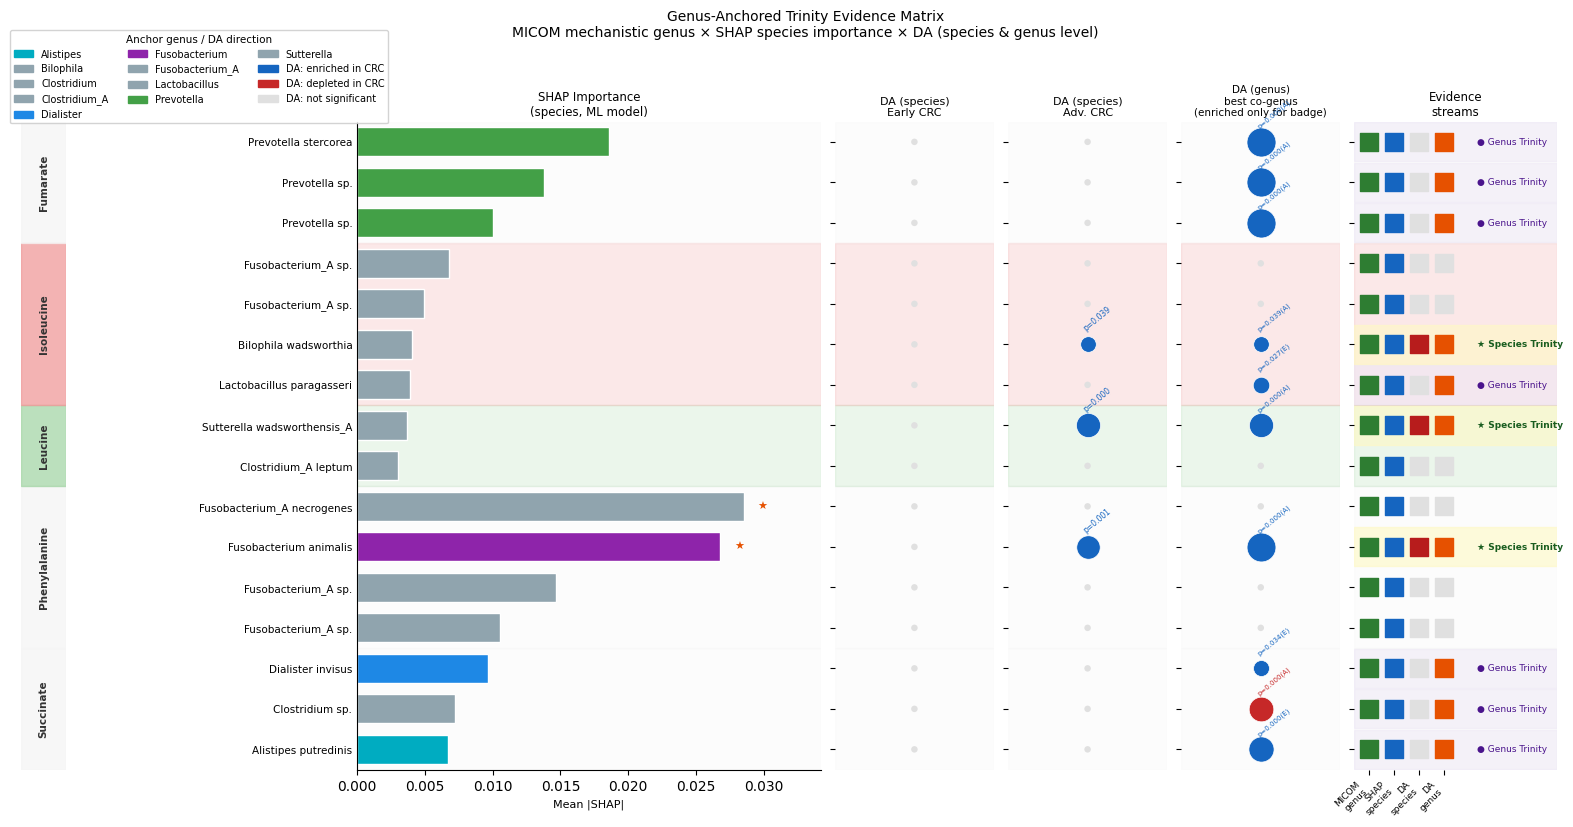

Saved → E:\D.Ani\Academic\KI\Results\figures\micom\nb09_genus_anchored_trinity_matrix.png

Species-level trinity (same MAG in all 3 streams): 3
  ★ Bilophila wadsworthia                              → Isoleucine  SHAP=0.0040   Adv p=0.039
  ★ Sutterella wadsworthensis_A                        → Leucine  SHAP=0.0037   Adv p=0.000
  ★ Fusobacterium animalis                             → Phenylalanine  SHAP=0.0268   Adv p=0.001

Genus-level trinity (co-genus DA enriched in CRC, incl. species-level): 10
  [T1.11: only DA-enriched co-genus species count — depleted co-genus excluded]
  ● [Prevotella          ] → Fumarate  Early p=0.006 (Prevotella melaninogenica) Adv p=0.000
  ● [Bilophila           ] → Isoleucine   Adv p=0.039
  ● [Lactobacillus       ] → Isoleucine  Early p=0.027 (Lactobacillus porci) Adv p=0.047
  ● [Sutterella          ] → Leucine  Early p=0.012 (Sutterella parvirubra) Adv p=0.000
  ● [Fusobacterium       ] → Phenylalanine  Early p=0.048 (Fusobacterium_A sp900015295) Adv

In [13]:
# ── Step 6b — Trinity Evidence Matrix: Genus-Anchored Corroboration ─────────────
# Shows all 15 genus-anchored species-metabolite pairs across three evidence
# streams. Trinity is assessed at two levels:
#   Species-level: same MAG in MICOM genus + SHAP + DA  (gold star)
#   Genus-level:   any co-genus species is DA-significant (silver star)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from pathlib import Path

TABLE_DIR_local = TABLE_DIR
FIG_DIR_local   = FIG_DIR / 'micom'
FIG_DIR_local.mkdir(parents=True, exist_ok=True)

_ga_path   = TABLE_DIR_local / "micom_shap_genus_anchored_species.csv"
_da_e_path = TABLE_DIR_local / "da_species_Healthy_vs_Early_CRC.csv"
_da_a_path = TABLE_DIR_local / "da_species_Healthy_vs_Advanced_CRC.csv"

if not _ga_path.exists():
    print("Run Step 6a first to generate micom_shap_genus_anchored_species.csv")
else:
    _ga  = pd.read_csv(_ga_path)
    _dae = pd.read_csv(_da_e_path)
    _daa = pd.read_csv(_da_a_path)

    _ga = _ga.sort_values(["metabolite", "shap_importance"], ascending=[True, False]).copy()
    _ga["epithet"]   = _ga["species"].str.split().str[-1]
    _ga["row_label"] = _ga["species"].apply(
        lambda s: " ".join(s.split()[:2]) if not s.split()[-1].startswith("sp") else
                  s.split()[0] + " sp."
    )

    # ── Species-level DA (exact epithet match, deduplicated) ──────────────────
    for _df in [_dae, _daa]:
        _df["epithet"] = _df["feature"].str.split().str[-1]
        _df["genus"]   = _df["feature"].str.split().str[0]

    # C3 FIX: named epithets (e.g. "varium") appear in multiple genera.
    # Use (genus, epithet) composite key to avoid cross-genus false matches.
    # MAG epithets (sp900XXXXXX) are globally unique and unaffected.
    # Strip GTDB suffixes so "Escherichia_A__coli" matches anchor_genus "Escherichia__coli".
    _dae["_key"] = _dae["genus"].str.replace(r"_[A-Z]+$", "", regex=True) + "__" + _dae["epithet"]
    _daa["_key"] = _daa["genus"].str.replace(r"_[A-Z]+$", "", regex=True) + "__" + _daa["epithet"]
    _ga["_key"]  = _ga["anchor_genus"] + "__" + _ga["epithet"]

    _dae_sp = (_dae[_dae["pval"] < 0.05]
               .sort_values("pval").drop_duplicates("_key", keep="first")
               .set_index("_key"))
    _daa_sp = (_daa[_daa["pval"] < 0.05]
               .sort_values("pval").drop_duplicates("_key", keep="first")
               .set_index("_key"))

    _ga["da_sp_e_p"]  = _ga["_key"].map(_dae_sp["pval"])
    _ga["da_sp_e_fc"] = _ga["_key"].map(_dae_sp["log2FC"])
    _ga["da_sp_a_p"]  = _ga["_key"].map(_daa_sp["pval"])
    _ga["da_sp_a_fc"] = _ga["_key"].map(_daa_sp["log2FC"])

    # ── Genus-level DA (best hit per genus) ────────────────────────────────────
    # Visualization: best-p per genus, any direction.
    # The dot color in the genus DA panel reflects the true direction of the
    # strongest DA signal in that genus (red=depleted, blue=enriched).
    # Badge logic (trinity_genus) uses a separate enriched-only genus set below
    # so a genus can show a red dot AND still earn the badge when a different
    # co-genus species is enriched (e.g. Fusobacterium: best-p = canifelinum
    # depleted, but animalis enriched -> red dot + badge is correct).
    _dae_gn = (_dae[_dae["pval"] < 0.05]
               .assign(_genus_norm=lambda df: df["genus"].str.replace(r"_[A-Z]+$", "", regex=True))
               .sort_values("pval").drop_duplicates("_genus_norm", keep="first")
               .set_index("_genus_norm"))
    _daa_gn = (_daa[_daa["pval"] < 0.05]
               .assign(_genus_norm=lambda df: df["genus"].str.replace(r"_[A-Z]+$", "", regex=True))
               .sort_values("pval").drop_duplicates("_genus_norm", keep="first")
               .set_index("_genus_norm"))

    _ga["da_gn_e_p"]    = _ga["anchor_genus"].map(_dae_gn["pval"])
    _ga["da_gn_e_fc"]   = _ga["anchor_genus"].map(_dae_gn["log2FC"])
    _ga["da_gn_e_feat"] = _ga["anchor_genus"].map(_dae_gn["feature"])
    _ga["da_gn_a_p"]    = _ga["anchor_genus"].map(_daa_gn["pval"])
    _ga["da_gn_a_fc"]   = _ga["anchor_genus"].map(_daa_gn["log2FC"])
    _ga["da_gn_a_feat"] = _ga["anchor_genus"].map(_daa_gn["feature"])

    # Species-level DA: requires enrichment (log2FC > 0).
    # A depleted species should not earn the gold-star species trinity badge.
    _ga["trinity_species"] = (
        (_ga["da_sp_e_p"].notna() & (_ga["da_sp_e_fc"].fillna(-999) > 0)) |
        (_ga["da_sp_a_p"].notna() & (_ga["da_sp_a_fc"].fillna(-999) > 0))
    )
    # C1 FIX (revised): Genus trinity badge requires that at least ONE enriched
    # (log2FC > 0) species exists in the genus — checked via a separate set,
    # independent of which species has the best p-value (used for visualization).
    # This decouples the dot color (best-p direction) from the badge (any enriched).
    # Strip GTDB suffixes so set membership matches NCBI anchor_genus.
    _enr_genera_e = {re.sub(r"_[A-Z]+$", "", g)
                     for g in _dae.loc[(_dae["pval"] < 0.05) & (_dae["log2FC"] > 0), "genus"]}
    _enr_genera_a = {re.sub(r"_[A-Z]+$", "", g)
                     for g in _daa.loc[(_daa["pval"] < 0.05) & (_daa["log2FC"] > 0), "genus"]}
    _ga["da_gn_e_enriched"] = _ga["anchor_genus"].isin(_enr_genera_e)
    _ga["da_gn_a_enriched"] = _ga["anchor_genus"].isin(_enr_genera_a)
    _ga["trinity_genus"]    = _ga["da_gn_e_enriched"] | _ga["da_gn_a_enriched"]
    _ga["any_trinity"]     = _ga["trinity_species"] | _ga["trinity_genus"]

    # ── Layout ────────────────────────────────────────────────────────────────
    GENUS_COLORS = {
        "Alistipes":      "#00ACC1", "Collinsella":    "#00897B",
        "Dialister":      "#1E88E5", "Escherichia":    "#E53935",
        "Fusobacterium":  "#8E24AA", "Intestinibacter":"#6D4C41",
        "Klebsiella":     "#FB8C00", "Megasphaera":    "#F06292",
        "Prevotella":     "#43A047", "Streptococcus":  "#FFB300",
    }
    MET_COLORS = {
        "Isoleucine": "#EF9A9A", "Lactate": "#90CAF9",
        "Leucine": "#A5D6A7",   "Riboflavin": "#FFF59D", "Urea": "#CE93D8",
    }

    n     = len(_ga)
    rows  = list(reversed(range(n)))
    _rev  = _ga.iloc[::-1].reset_index(drop=True)

    fig = plt.figure(figsize=(16, 8))
    gs  = gridspec.GridSpec(1, 5, width_ratios=[3.2, 1.1, 1.1, 1.1, 1.4],
                            wspace=0.06, left=0.22, right=0.97,
                            top=0.88, bottom=0.07)
    ax_shap = fig.add_subplot(gs[0])
    ax_dse  = fig.add_subplot(gs[1])   # species DA early
    ax_dsa  = fig.add_subplot(gs[2])   # species DA adv
    ax_dge  = fig.add_subplot(gs[3])   # genus DA early/adv combined
    ax_tri  = fig.add_subplot(gs[4])   # evidence tiles

    # metabolite background bands
    _met_grp = {}
    for i, row in _rev.iterrows():
        _met_grp.setdefault(row["metabolite"], []).append(i)
    for _ax in [ax_shap, ax_dse, ax_dsa, ax_dge, ax_tri]:
        for _m, idxs in _met_grp.items():
            lo, hi = min(idxs) - 0.5, max(idxs) + 0.5
            _ax.axhspan(lo, hi, color=MET_COLORS.get(_m, "#F5F5F5"), alpha=0.22, zorder=0)

    # ── Left metabolite label strip ───────────────────────────────────────────
    ax_met = fig.add_axes([0.01, 0.07, 0.028, 0.81])
    ax_met.set_xlim(0, 1)
    ax_met.set_ylim(-0.5, n - 0.5)
    ax_met.set_axis_off()
    for _m, idxs in _met_grp.items():
        lo, hi = min(idxs) - 0.5, max(idxs) + 0.5
        mid    = (lo + hi) / 2
        col    = MET_COLORS.get(_m, "#F5F5F5")
        ax_met.axhspan(lo, hi, color=col, alpha=0.75, zorder=0)
        ax_met.text(0.5, mid, _m, ha="center", va="center",
                    fontsize=7.5, fontweight="bold", color="#333333",
                    rotation=90, zorder=1)

    # ── Panel 1: SHAP bars ────────────────────────────────────────────────────
    for i, row in _rev.iterrows():
        col = GENUS_COLORS.get(row["anchor_genus"], "#90A4AE")
        ax_shap.barh(i, row["shap_importance"], color=col, height=0.72,
                     edgecolor="white", zorder=2)
        if row["shap_importance"] > 0.02:
            ax_shap.text(row["shap_importance"] + 0.001, i, "★",
                         va="center", fontsize=8, color="#E65100", zorder=3)
    ax_shap.set_yticks(range(n))
    ax_shap.set_yticklabels(_rev["row_label"], fontsize=7.5)
    ax_shap.set_xlabel("Mean |SHAP|", fontsize=8)
    ax_shap.set_title("SHAP Importance\n(species, ML model)", fontsize=8.5, pad=4)
    ax_shap.set_xlim(0, _rev["shap_importance"].max() * 1.2)
    ax_shap.tick_params(axis="y", length=0)
    ax_shap.spines[["top","right"]].set_visible(False)
    ax_shap.set_ylim(-0.5, n - 0.5)

    def _da_dot_panel(ax, p_col, fc_col, title):
        for i, row in _rev.iterrows():
            p  = row[p_col]
            fc = row[fc_col]
            if pd.notna(p):
                col  = "#C62828" if (pd.notna(fc) and fc < 0) else "#1565C0"
                size = max(55, -np.log10(p) * 90)
                ax.scatter(0.5, i, s=size, color=col, zorder=3,
                           edgecolors="white", linewidths=0.5)
                ax.text(0.5, i + 0.30, f"p={p:.3f}",
                        ha="left", va="bottom", fontsize=5.5, color=col, zorder=4,
                        rotation=40, rotation_mode="anchor")
            else:
                ax.scatter(0.5, i, s=22, color="#E0E0E0", zorder=2, edgecolors="none")
        ax.set_xlim(0, 1); ax.set_xticks([]); ax.set_yticks(range(n))
        ax.set_yticklabels([]); ax.set_title(title, fontsize=8, pad=4)
        ax.spines[["top","right","left","bottom"]].set_visible(False)
        ax.set_ylim(-0.5, n - 0.5)

    _da_dot_panel(ax_dse, "da_sp_e_p", "da_sp_e_fc",
                  "DA (species)\nEarly CRC")
    _da_dot_panel(ax_dsa, "da_sp_a_p", "da_sp_a_fc",
                  "DA (species)\nAdv. CRC")

    # Genus DA panel: show best hit (early or adv, whichever smaller p)
    for i, row in _rev.iterrows():
        ep, efc = row["da_gn_e_p"], row["da_gn_e_fc"]
        ap, afc = row["da_gn_a_p"], row["da_gn_a_fc"]
        # pick best p
        if pd.notna(ep) and (not pd.notna(ap) or ep <= ap):
            p, fc, stage = ep, efc, "E"
        elif pd.notna(ap):
            p, fc, stage = ap, afc, "A"
        else:
            p = fc = float("nan"); stage = ""
        if pd.notna(p):
            col  = "#C62828" if (pd.notna(fc) and fc < 0) else "#1565C0"
            size = max(55, -np.log10(p) * 90)
            ax_dge.scatter(0.5, i, s=size, color=col, zorder=3,
                           edgecolors="white", linewidths=0.5)
            ax_dge.text(0.5, i + 0.30, f"p={p:.3f}({stage})",
                        ha="left", va="bottom", fontsize=5, color=col, zorder=4,
                        rotation=40, rotation_mode="anchor")
        else:
            ax_dge.scatter(0.5, i, s=22, color="#E0E0E0", zorder=2, edgecolors="none")
    ax_dge.set_xlim(0, 1); ax_dge.set_xticks([]); ax_dge.set_yticks(range(n))
    ax_dge.set_yticklabels([]); ax_dge.set_title("DA (genus)\nbest co-genus\n(enriched only for badge)", fontsize=7.5, pad=4)
    ax_dge.spines[["top","right","left","bottom"]].set_visible(False)
    ax_dge.set_ylim(-0.5, n - 0.5)

    # ── Panel 5: Evidence tiles + trinity badges ───────────────────────────────
    STREAMS = ["MICOM\ngenus", "SHAP\nspecies", "DA\nspecies", "DA\ngenus"]
    for i, row in _rev.iterrows():
        ax_tri.scatter(0, i, s=150, color="#2E7D32", marker="s", zorder=3)  # MICOM always
        ax_tri.scatter(1, i, s=150, color="#1565C0", marker="s", zorder=3)  # SHAP always
        # Species-level DA
        sp_da = row["trinity_species"]
        ax_tri.scatter(2, i, s=150,
                       color="#B71C1C" if sp_da else "#E0E0E0",
                       marker="s", zorder=3)
        # Genus-level DA
        gn_da = row["trinity_genus"]
        ax_tri.scatter(3, i, s=150,
                       color="#E65100" if gn_da else "#E0E0E0",
                       marker="s", zorder=3)
        # Labels
        if sp_da:
            ax_tri.text(4.3, i, "★ Species Trinity", va="center",
                        fontsize=6.5, fontweight="bold", color="#1B5E20")
        elif gn_da:
            ax_tri.text(4.3, i, "● Genus Trinity", va="center",
                        fontsize=6.5, color="#4A148C")
        # Highlight background
        if sp_da:
            ax_tri.axhspan(i-0.48, i+0.48, xmin=0, xmax=1,
                           color="#FFF9C4", alpha=0.6, zorder=1)
        elif gn_da:
            ax_tri.axhspan(i-0.48, i+0.48, xmin=0, xmax=1,
                           color="#EDE7F6", alpha=0.5, zorder=1)

    ax_tri.set_xticks([0,1,2,3])
    ax_tri.set_xticklabels(STREAMS, fontsize=6.5, rotation=45, ha="right")
    ax_tri.set_yticks(range(n)); ax_tri.set_yticklabels([])
    ax_tri.set_xlim(-0.6, 7.5)
    ax_tri.set_title("Evidence\nstreams", fontsize=8.5, pad=4)
    ax_tri.spines[["top","right","left","bottom"]].set_visible(False)
    ax_tri.set_ylim(-0.5, n - 0.5)

    # ── Legend ────────────────────────────────────────────────────────────────
    genus_patches = [mpatches.Patch(color=GENUS_COLORS.get(g,"#90A4AE"), label=g)
                     for g in sorted(set(_rev["anchor_genus"]))]
    da_patches = [
        mpatches.Patch(color="#1565C0", label="DA: enriched in CRC"),
        mpatches.Patch(color="#C62828", label="DA: depleted in CRC"),
        mpatches.Patch(color="#E0E0E0", label="DA: not significant"),
    ]
    fig.legend(handles=genus_patches + da_patches,
               loc="upper left", bbox_to_anchor=(0.0, 1.0),
               ncol=3, fontsize=7, framealpha=0.85,
               title="Anchor genus / DA direction", title_fontsize=7.5)

    fig.suptitle(
        "Genus-Anchored Trinity Evidence Matrix\n"
        "MICOM mechanistic genus × SHAP species importance "
        "× DA (species & genus level)",
        fontsize=10, y=1.02
    )

    _out = FIG_DIR_local / "nb09_genus_anchored_trinity_matrix.png"
    fig.savefig(_out, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved → {_out}")

    # ── Summary ───────────────────────────────────────────────────────────────
    n_sp = int(_ga["trinity_species"].sum())
    n_gn = int(_ga["trinity_genus"].sum())
    print(f"\nSpecies-level trinity (same MAG in all 3 streams): {n_sp}")
    for _, r in _ga[_ga["trinity_species"]].iterrows():
        es = f"Early p={r['da_sp_e_p']:.3f}" if pd.notna(r['da_sp_e_p']) else ""
        av = f"Adv p={r['da_sp_a_p']:.3f}" if pd.notna(r['da_sp_a_p']) else ""
        print(f"  ★ {r['species']:50s} → {r['metabolite']}  SHAP={r['shap_importance']:.4f}  {es} {av}")

    print(f"\nGenus-level trinity (co-genus DA enriched in CRC, incl. species-level): {n_gn}")
    print("  [T1.11: only DA-enriched co-genus species count — depleted co-genus excluded]")
    shown = set()
    for _, r in _ga[_ga["trinity_genus"]].iterrows():
        key = (r["anchor_genus"], r["metabolite"])
        if key in shown: continue
        shown.add(key)
        es = f"Early p={r['da_gn_e_p']:.3f} ({r['da_gn_e_feat']})" if pd.notna(r['da_gn_e_p']) else ""
        av = f"Adv p={r['da_gn_a_p']:.3f}" if pd.notna(r['da_gn_a_p']) else ""
        print(f"  ● [{r['anchor_genus']:20s}] → {r['metabolite']}  {es} {av}")


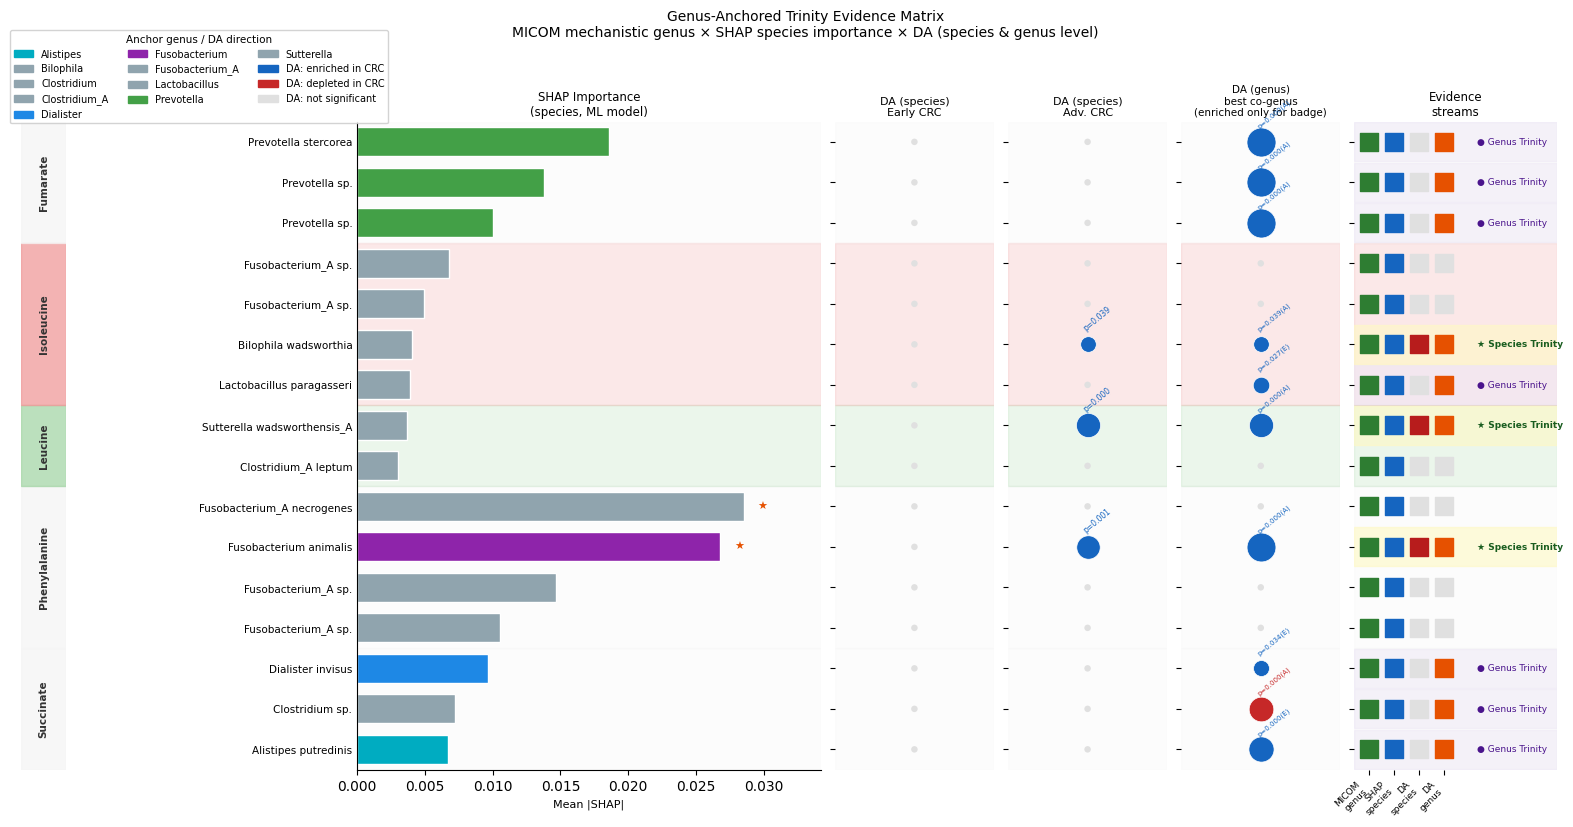

Saved → E:\D.Ani\Academic\KI\Results\figures\micom\nb09_genus_anchored_trinity_matrix.png
Saved → E:\D.Ani\Academic\KI\Results\figures\micom\nb09_genus_anchored_trinity_matrix.pdf

Species-level trinity (same MAG in all 3 streams): 3
  ★ Bilophila wadsworthia                              → Isoleucine  SHAP=0.0040   Adv p=0.039
  ★ Sutterella wadsworthensis_A                        → Leucine  SHAP=0.0037   Adv p=0.000
  ★ Fusobacterium animalis                             → Phenylalanine  SHAP=0.0268   Adv p=0.001

Genus-level trinity (co-genus DA enriched in CRC, incl. species-level): 10
  [T1.11: only DA-enriched co-genus species count — depleted co-genus excluded]
  ● [Prevotella          ] → Fumarate  Early p=0.006 (Prevotella melaninogenica) Adv p=0.000
  ● [Bilophila           ] → Isoleucine   Adv p=0.039
  ● [Lactobacillus       ] → Isoleucine  Early p=0.027 (Lactobacillus porci) Adv p=0.047
  ● [Sutterella          ] → Leucine  Early p=0.012 (Sutterella parvirubra) Adv p=0.000
 

In [14]:
# ── Step 6b — Trinity Evidence Matrix: Genus-Anchored Corroboration ─────────────
# Shows all 15 genus-anchored species-metabolite pairs across three evidence
# streams. Trinity is assessed at two levels:
#   Species-level: same MAG in MICOM genus + SHAP + DA  (gold star)
#   Genus-level:   any co-genus species is DA-significant (silver star)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from pathlib import Path

TABLE_DIR_local = TABLE_DIR
FIG_DIR_local   = FIG_DIR / 'micom'
FIG_DIR_local.mkdir(parents=True, exist_ok=True)

_ga_path   = TABLE_DIR_local / "micom_shap_genus_anchored_species.csv"
_da_e_path = TABLE_DIR_local / "da_species_Healthy_vs_Early_CRC.csv"
_da_a_path = TABLE_DIR_local / "da_species_Healthy_vs_Advanced_CRC.csv"

if not _ga_path.exists():
    print("Run Step 6a first to generate micom_shap_genus_anchored_species.csv")
else:
    _ga  = pd.read_csv(_ga_path)
    _dae = pd.read_csv(_da_e_path)
    _daa = pd.read_csv(_da_a_path)

    _ga = _ga.sort_values(["metabolite", "shap_importance"], ascending=[True, False]).copy()
    _ga["epithet"]   = _ga["species"].str.split().str[-1]
    _ga["row_label"] = _ga["species"].apply(
        lambda s: " ".join(s.split()[:2]) if not s.split()[-1].startswith("sp") else
                  s.split()[0] + " sp."
    )

    # ── Species-level DA (exact epithet match, deduplicated) ──────────────────
    for _df in [_dae, _daa]:
        _df["epithet"] = _df["feature"].str.split().str[-1]
        _df["genus"]   = _df["feature"].str.split().str[0]

    # C3 FIX: named epithets (e.g. "varium") appear in multiple genera.
    # Use (genus, epithet) composite key to avoid cross-genus false matches.
    # MAG epithets (sp900XXXXXX) are globally unique and unaffected.
    # Strip GTDB suffixes so "Escherichia_A__coli" matches anchor_genus "Escherichia__coli".
    _dae["_key"] = _dae["genus"].str.replace(r"_[A-Z]+$", "", regex=True) + "__" + _dae["epithet"]
    _daa["_key"] = _daa["genus"].str.replace(r"_[A-Z]+$", "", regex=True) + "__" + _daa["epithet"]
    _ga["_key"]  = _ga["anchor_genus"] + "__" + _ga["epithet"]

    _dae_sp = (_dae[_dae["pval"] < 0.05]
               .sort_values("pval").drop_duplicates("_key", keep="first")
               .set_index("_key"))
    _daa_sp = (_daa[_daa["pval"] < 0.05]
               .sort_values("pval").drop_duplicates("_key", keep="first")
               .set_index("_key"))

    _ga["da_sp_e_p"]  = _ga["_key"].map(_dae_sp["pval"])
    _ga["da_sp_e_fc"] = _ga["_key"].map(_dae_sp["log2FC"])
    _ga["da_sp_a_p"]  = _ga["_key"].map(_daa_sp["pval"])
    _ga["da_sp_a_fc"] = _ga["_key"].map(_daa_sp["log2FC"])

    # ── Genus-level DA (best hit per genus) ────────────────────────────────────
    # Visualization: best-p per genus, any direction.
    # The dot color in the genus DA panel reflects the true direction of the
    # strongest DA signal in that genus (red=depleted, blue=enriched).
    # Badge logic (trinity_genus) uses a separate enriched-only genus set below
    # so a genus can show a red dot AND still earn the badge when a different
    # co-genus species is enriched (e.g. Fusobacterium: best-p = canifelinum
    # depleted, but animalis enriched -> red dot + badge is correct).
    _dae_gn = (_dae[_dae["pval"] < 0.05]
               .assign(_genus_norm=lambda df: df["genus"].str.replace(r"_[A-Z]+$", "", regex=True))
               .sort_values("pval").drop_duplicates("_genus_norm", keep="first")
               .set_index("_genus_norm"))
    _daa_gn = (_daa[_daa["pval"] < 0.05]
               .assign(_genus_norm=lambda df: df["genus"].str.replace(r"_[A-Z]+$", "", regex=True))
               .sort_values("pval").drop_duplicates("_genus_norm", keep="first")
               .set_index("_genus_norm"))

    _ga["da_gn_e_p"]    = _ga["anchor_genus"].map(_dae_gn["pval"])
    _ga["da_gn_e_fc"]   = _ga["anchor_genus"].map(_dae_gn["log2FC"])
    _ga["da_gn_e_feat"] = _ga["anchor_genus"].map(_dae_gn["feature"])
    _ga["da_gn_a_p"]    = _ga["anchor_genus"].map(_daa_gn["pval"])
    _ga["da_gn_a_fc"]   = _ga["anchor_genus"].map(_daa_gn["log2FC"])
    _ga["da_gn_a_feat"] = _ga["anchor_genus"].map(_daa_gn["feature"])

    # Species-level DA: requires enrichment (log2FC > 0).
    # A depleted species should not earn the gold-star species trinity badge.
    _ga["trinity_species"] = (
        (_ga["da_sp_e_p"].notna() & (_ga["da_sp_e_fc"].fillna(-999) > 0)) |
        (_ga["da_sp_a_p"].notna() & (_ga["da_sp_a_fc"].fillna(-999) > 0))
    )
    # C1 FIX (revised): Genus trinity badge requires that at least ONE enriched
    # (log2FC > 0) species exists in the genus — checked via a separate set,
    # independent of which species has the best p-value (used for visualization).
    # This decouples the dot color (best-p direction) from the badge (any enriched).
    # Strip GTDB suffixes so set membership matches NCBI anchor_genus.
    _enr_genera_e = {re.sub(r"_[A-Z]+$", "", g)
                     for g in _dae.loc[(_dae["pval"] < 0.05) & (_dae["log2FC"] > 0), "genus"]}
    _enr_genera_a = {re.sub(r"_[A-Z]+$", "", g)
                     for g in _daa.loc[(_daa["pval"] < 0.05) & (_daa["log2FC"] > 0), "genus"]}
    _ga["da_gn_e_enriched"] = _ga["anchor_genus"].isin(_enr_genera_e)
    _ga["da_gn_a_enriched"] = _ga["anchor_genus"].isin(_enr_genera_a)
    _ga["trinity_genus"]    = _ga["da_gn_e_enriched"] | _ga["da_gn_a_enriched"]
    _ga["any_trinity"]     = _ga["trinity_species"] | _ga["trinity_genus"]

    # ── Layout ────────────────────────────────────────────────────────────────
    GENUS_COLORS = {
        "Alistipes":      "#00ACC1", "Collinsella":    "#00897B",
        "Dialister":      "#1E88E5", "Escherichia":    "#E53935",
        "Fusobacterium":  "#8E24AA", "Intestinibacter":"#6D4C41",
        "Klebsiella":     "#FB8C00", "Megasphaera":    "#F06292",
        "Prevotella":     "#43A047", "Streptococcus":  "#FFB300",
    }
    MET_COLORS = {
        "Isoleucine": "#EF9A9A", "Lactate": "#90CAF9",
        "Leucine": "#A5D6A7",   "Riboflavin": "#FFF59D", "Urea": "#CE93D8",
    }

    n     = len(_ga)
    rows  = list(reversed(range(n)))
    _rev  = _ga.iloc[::-1].reset_index(drop=True)

    fig = plt.figure(figsize=(16, 8))
    gs  = gridspec.GridSpec(1, 5, width_ratios=[3.2, 1.1, 1.1, 1.1, 1.4],
                            wspace=0.06, left=0.22, right=0.97,
                            top=0.88, bottom=0.07)
    ax_shap = fig.add_subplot(gs[0])
    ax_dse  = fig.add_subplot(gs[1])   # species DA early
    ax_dsa  = fig.add_subplot(gs[2])   # species DA adv
    ax_dge  = fig.add_subplot(gs[3])   # genus DA early/adv combined
    ax_tri  = fig.add_subplot(gs[4])   # evidence tiles

    # metabolite background bands
    _met_grp = {}
    for i, row in _rev.iterrows():
        _met_grp.setdefault(row["metabolite"], []).append(i)
    for _ax in [ax_shap, ax_dse, ax_dsa, ax_dge, ax_tri]:
        for _m, idxs in _met_grp.items():
            lo, hi = min(idxs) - 0.5, max(idxs) + 0.5
            _ax.axhspan(lo, hi, color=MET_COLORS.get(_m, "#F5F5F5"), alpha=0.22, zorder=0)

    # ── Left metabolite label strip ───────────────────────────────────────────
    ax_met = fig.add_axes([0.01, 0.07, 0.028, 0.81])
    ax_met.set_xlim(0, 1)
    ax_met.set_ylim(-0.5, n - 0.5)
    ax_met.set_axis_off()
    for _m, idxs in _met_grp.items():
        lo, hi = min(idxs) - 0.5, max(idxs) + 0.5
        mid    = (lo + hi) / 2
        col    = MET_COLORS.get(_m, "#F5F5F5")
        ax_met.axhspan(lo, hi, color=col, alpha=0.75, zorder=0)
        ax_met.text(0.5, mid, _m, ha="center", va="center",
                    fontsize=7.5, fontweight="bold", color="#333333",
                    rotation=90, zorder=1)

    # ── Panel 1: SHAP bars ────────────────────────────────────────────────────
    for i, row in _rev.iterrows():
        col = GENUS_COLORS.get(row["anchor_genus"], "#90A4AE")
        ax_shap.barh(i, row["shap_importance"], color=col, height=0.72,
                     edgecolor="white", zorder=2)
        if row["shap_importance"] > 0.02:
            ax_shap.text(row["shap_importance"] + 0.001, i, "★",
                         va="center", fontsize=8, color="#E65100", zorder=3)
    ax_shap.set_yticks(range(n))
    ax_shap.set_yticklabels(_rev["row_label"], fontsize=7.5)
    ax_shap.set_xlabel("Mean |SHAP|", fontsize=8)
    ax_shap.set_title("SHAP Importance\n(species, ML model)", fontsize=8.5, pad=4)
    ax_shap.set_xlim(0, _rev["shap_importance"].max() * 1.2)
    ax_shap.tick_params(axis="y", length=0)
    ax_shap.spines[["top","right"]].set_visible(False)
    ax_shap.set_ylim(-0.5, n - 0.5)

    def _da_dot_panel(ax, p_col, fc_col, title):
        for i, row in _rev.iterrows():
            p  = row[p_col]
            fc = row[fc_col]
            if pd.notna(p):
                col  = "#C62828" if (pd.notna(fc) and fc < 0) else "#1565C0"
                size = max(55, -np.log10(p) * 90)
                ax.scatter(0.5, i, s=size, color=col, zorder=3,
                           edgecolors="white", linewidths=0.5)
                ax.text(0.5, i + 0.30, f"p={p:.3f}",
                        ha="left", va="bottom", fontsize=5.5, color=col, zorder=4,
                        rotation=40, rotation_mode="anchor")
            else:
                ax.scatter(0.5, i, s=22, color="#E0E0E0", zorder=2, edgecolors="none")
        ax.set_xlim(0, 1); ax.set_xticks([]); ax.set_yticks(range(n))
        ax.set_yticklabels([]); ax.set_title(title, fontsize=8, pad=4)
        ax.spines[["top","right","left","bottom"]].set_visible(False)
        ax.set_ylim(-0.5, n - 0.5)

    _da_dot_panel(ax_dse, "da_sp_e_p", "da_sp_e_fc",
                  "DA (species)\nEarly CRC")
    _da_dot_panel(ax_dsa, "da_sp_a_p", "da_sp_a_fc",
                  "DA (species)\nAdv. CRC")

    # Genus DA panel: show best hit (early or adv, whichever smaller p)
    for i, row in _rev.iterrows():
        ep, efc = row["da_gn_e_p"], row["da_gn_e_fc"]
        ap, afc = row["da_gn_a_p"], row["da_gn_a_fc"]
        # pick best p
        if pd.notna(ep) and (not pd.notna(ap) or ep <= ap):
            p, fc, stage = ep, efc, "E"
        elif pd.notna(ap):
            p, fc, stage = ap, afc, "A"
        else:
            p = fc = float("nan"); stage = ""
        if pd.notna(p):
            col  = "#C62828" if (pd.notna(fc) and fc < 0) else "#1565C0"
            size = max(55, -np.log10(p) * 90)
            ax_dge.scatter(0.5, i, s=size, color=col, zorder=3,
                           edgecolors="white", linewidths=0.5)
            ax_dge.text(0.5, i + 0.30, f"p={p:.3f}({stage})",
                        ha="left", va="bottom", fontsize=5, color=col, zorder=4,
                        rotation=40, rotation_mode="anchor")
        else:
            ax_dge.scatter(0.5, i, s=22, color="#E0E0E0", zorder=2, edgecolors="none")
    ax_dge.set_xlim(0, 1); ax_dge.set_xticks([]); ax_dge.set_yticks(range(n))
    ax_dge.set_yticklabels([]); ax_dge.set_title("DA (genus)\nbest co-genus\n(enriched only for badge)", fontsize=7.5, pad=4)
    ax_dge.spines[["top","right","left","bottom"]].set_visible(False)
    ax_dge.set_ylim(-0.5, n - 0.5)

    # ── Panel 5: Evidence tiles + trinity badges ───────────────────────────────
    STREAMS = ["MICOM\ngenus", "SHAP\nspecies", "DA\nspecies", "DA\ngenus"]
    for i, row in _rev.iterrows():
        ax_tri.scatter(0, i, s=150, color="#2E7D32", marker="s", zorder=3)  # MICOM always
        ax_tri.scatter(1, i, s=150, color="#1565C0", marker="s", zorder=3)  # SHAP always
        # Species-level DA
        sp_da = row["trinity_species"]
        ax_tri.scatter(2, i, s=150,
                       color="#B71C1C" if sp_da else "#E0E0E0",
                       marker="s", zorder=3)
        # Genus-level DA
        gn_da = row["trinity_genus"]
        ax_tri.scatter(3, i, s=150,
                       color="#E65100" if gn_da else "#E0E0E0",
                       marker="s", zorder=3)
        # Labels
        if sp_da:
            ax_tri.text(4.3, i, "★ Species Trinity", va="center",
                        fontsize=6.5, fontweight="bold", color="#1B5E20")
        elif gn_da:
            ax_tri.text(4.3, i, "● Genus Trinity", va="center",
                        fontsize=6.5, color="#4A148C")
        # Highlight background
        if sp_da:
            ax_tri.axhspan(i-0.48, i+0.48, xmin=0, xmax=1,
                           color="#FFF9C4", alpha=0.6, zorder=1)
        elif gn_da:
            ax_tri.axhspan(i-0.48, i+0.48, xmin=0, xmax=1,
                           color="#EDE7F6", alpha=0.5, zorder=1)

    ax_tri.set_xticks([0,1,2,3])
    ax_tri.set_xticklabels(STREAMS, fontsize=6.5, rotation=45, ha="right")
    ax_tri.set_yticks(range(n)); ax_tri.set_yticklabels([])
    ax_tri.set_xlim(-0.6, 7.5)
    ax_tri.set_title("Evidence\nstreams", fontsize=8.5, pad=4)
    ax_tri.spines[["top","right","left","bottom"]].set_visible(False)
    ax_tri.set_ylim(-0.5, n - 0.5)

    # ── Legend ────────────────────────────────────────────────────────────────
    genus_patches = [mpatches.Patch(color=GENUS_COLORS.get(g,"#90A4AE"), label=g)
                     for g in sorted(set(_rev["anchor_genus"]))]
    da_patches = [
        mpatches.Patch(color="#1565C0", label="DA: enriched in CRC"),
        mpatches.Patch(color="#C62828", label="DA: depleted in CRC"),
        mpatches.Patch(color="#E0E0E0", label="DA: not significant"),
    ]
    fig.legend(handles=genus_patches + da_patches,
               loc="upper left", bbox_to_anchor=(0.0, 1.0),
               ncol=3, fontsize=7, framealpha=0.85,
               title="Anchor genus / DA direction", title_fontsize=7.5)

    fig.suptitle(
        "Genus-Anchored Trinity Evidence Matrix\n"
        "MICOM mechanistic genus × SHAP species importance "
        "× DA (species & genus level)",
        fontsize=10, y=1.02
    )

    # --- NEW: Save as both PNG and PDF ---
    _out_png = FIG_DIR_local / "nb09_genus_anchored_trinity_matrix.png"
    _out_pdf = FIG_DIR_local / "nb09_genus_anchored_trinity_matrix.pdf"
    
    fig.savefig(_out_png, dpi=180, bbox_inches="tight")
    fig.savefig(_out_pdf, bbox_inches="tight")
    
    plt.show()
    print(f"Saved → {_out_png}")
    print(f"Saved → {_out_pdf}")

    # ── Summary ───────────────────────────────────────────────────────────────
    n_sp = int(_ga["trinity_species"].sum())
    n_gn = int(_ga["trinity_genus"].sum())
    print(f"\nSpecies-level trinity (same MAG in all 3 streams): {n_sp}")
    for _, r in _ga[_ga["trinity_species"]].iterrows():
        es = f"Early p={r['da_sp_e_p']:.3f}" if pd.notna(r['da_sp_e_p']) else ""
        av = f"Adv p={r['da_sp_a_p']:.3f}" if pd.notna(r['da_sp_a_p']) else ""
        print(f"  ★ {r['species']:50s} → {r['metabolite']}  SHAP={r['shap_importance']:.4f}  {es} {av}")

    print(f"\nGenus-level trinity (co-genus DA enriched in CRC, incl. species-level): {n_gn}")
    print("  [T1.11: only DA-enriched co-genus species count — depleted co-genus excluded]")
    shown = set()
    for _, r in _ga[_ga["trinity_genus"]].iterrows():
        key = (r["anchor_genus"], r["metabolite"])
        if key in shown: continue
        shown.add(key)
        es = f"Early p={r['da_gn_e_p']:.3f} ({r['da_gn_e_feat']})" if pd.notna(r['da_gn_e_p']) else ""
        av = f"Adv p={r['da_gn_a_p']:.3f}" if pd.notna(r['da_gn_a_p']) else ""
        print(f"  ● [{r['anchor_genus']:20s}] → {r['metabolite']}  {es} {av}")

Using agora_pairs from Cell 6  (587 species)

Top-30 SHAP species — AGORA103 coverage
  Covered   :   4 species  SHAP mass = 0.7884  (20.9%)
  Uncovered :  26 species  SHAP mass = 2.9811  (79.1%)

Uncovered species (sorted by SHAP importance):
                                species  shap_importance
           Anaeroglobus micronuciformis         0.230505
                     QAND01 sp003150225         0.188346
                Lachnospira sp000436535         0.170652
Pullichristensenella excrementipullorum         0.165394
                Lachnospira sp000437735         0.145302
Pullichristensenella stercorigallinarum         0.133842
                 Alistipes avistercoris         0.132821
                  Ruminococcus_B gnavus         0.132656
                  Romboutsia timonensis         0.130231
         Ruthenibacterium merdipullorum         0.127436
            Pararuminococcus gallinarum         0.126110
  Pullichristensenella stercoripullorum         0.122962
               

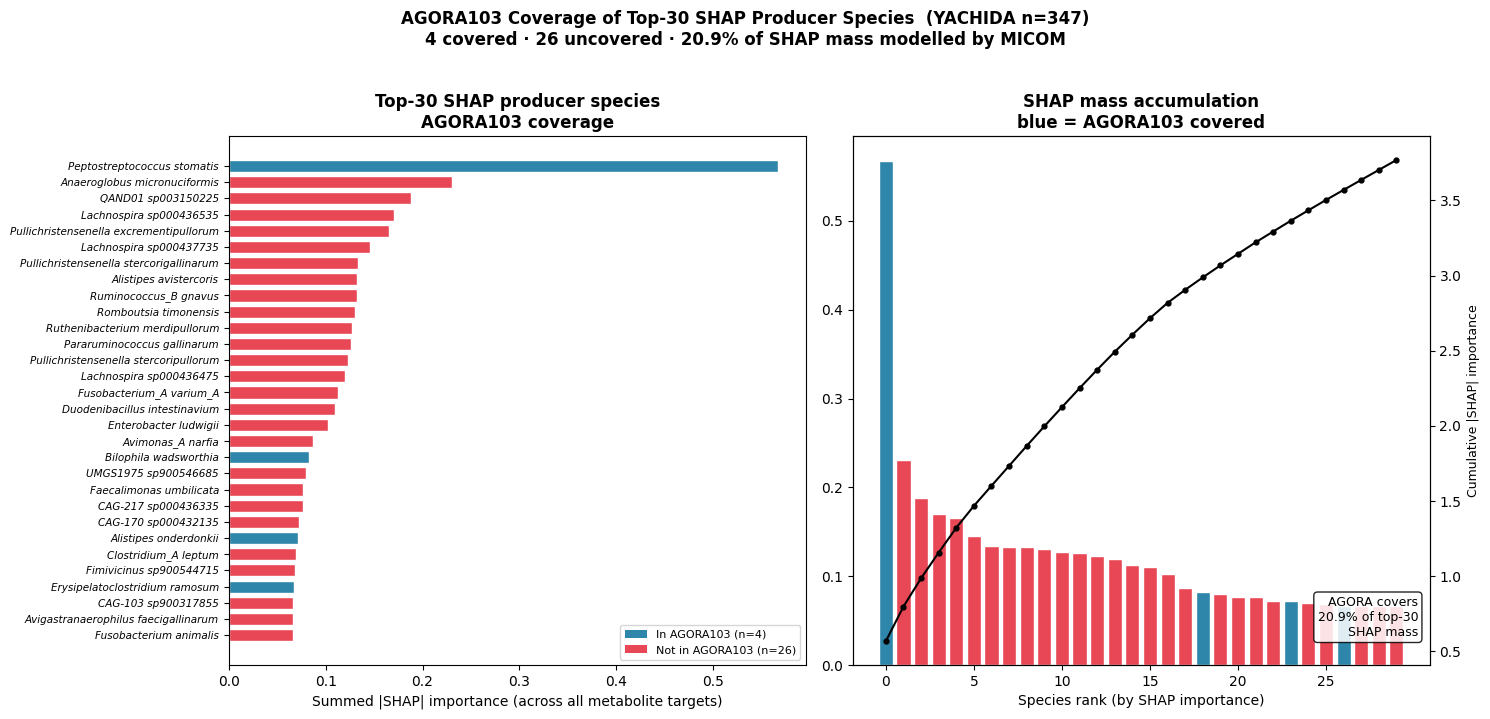

In [15]:
# ── Step 6c · SHAP-weighted AGORA103 coverage ─────────────────────────────
# Cross-references the top-N SHAP producer species against AGORA103 matched
# species and reports what fraction of cumulative SHAP importance mass is
# covered vs uncovered by the metabolic reconstruction database.
# Standalone: loads shap_producer_candidates.csv; uses agora_pairs from Cell 6
# (or reconstructs from the extracted AGORA manifest on disk as fallback).

import re
from pathlib import Path

# 1 · Load SHAP producer candidates ──────────────────────────────────────────────
shap_cov = pd.read_csv(TABLE_DIR / "shap_producer_candidates.csv")
shap_cov["genus"]   = shap_cov["species"].str.split().str[0]
shap_cov["epithet"] = shap_cov["species"].str.split().str[-1]

# Aggregate total SHAP mass per species across all metabolite targets
shap_per_species = (
    shap_cov.groupby(["species", "genus", "epithet"])["shap_importance"]
    .sum()
    .reset_index()
    .sort_values("shap_importance", ascending=False)
    .reset_index(drop=True)
)

N_TOP = 30
top_sp = shap_per_species.head(N_TOP).copy()

# 2 · Reconstruct AGORA (genus, epithet) pairs ──────────────────────────────────────────
# Prefer variable from Cell 6; fall back to scanning extracted manifest on disk
_agora_pairs = None
if "agora_pairs" in dir():
    _agora_pairs = agora_pairs
    print(f"Using agora_pairs from Cell 6  ({len(_agora_pairs)} species)")
else:
    _base = DATA_DIR / "micom" / "agora_extracted"
    for _p in sorted(Path(_base).rglob("*.csv")):
        try:
            _df = pd.read_csv(_p)
            if {"genus", "species"}.issubset(_df.columns):
                _agora_pairs = set(zip(_df["genus"].str.strip(), _df["species"].str.strip()))
                print(f"Loaded AGORA manifest from {_p.name}  ({len(_agora_pairs)} species)")
                break
        except Exception:
            continue

if _agora_pairs is None:
    raise RuntimeError("Cannot find agora_pairs — run Cell 6 first or check AGORA manifest path")

# 3 · Match SHAP species to AGORA ─────────────────────────────────────────────────────
_MAG_PATTERN = re.compile(r"^sp\d{6,}")  # sp000XXXXX / sp900XXXXX = uncultured MAG

def _agora_match(genus: str, epithet: str, pairs: set) -> bool:
    if _MAG_PATTERN.match(str(epithet)):
        return False
    if (genus, epithet) in pairs:
        return True
    genus_clean = re.sub(r"_[A-Z]+$", "", str(genus))
    return (genus_clean, epithet) in pairs

top_sp["in_agora"] = top_sp.apply(
    lambda r: _agora_match(r["genus"], r["epithet"], _agora_pairs), axis=1
)

# 4 · Summary statistics ────────────────────────────────────────────────────────────────
total_mass     = top_sp["shap_importance"].sum()
covered_mass   = top_sp.loc[top_sp["in_agora"],  "shap_importance"].sum()
uncovered_mass = top_sp.loc[~top_sp["in_agora"], "shap_importance"].sum()
pct_covered    = covered_mass  / total_mass * 100
n_covered      = int(top_sp["in_agora"].sum())
n_uncovered    = int((~top_sp["in_agora"]).sum())

print(f"\nTop-{N_TOP} SHAP species \u2014 AGORA103 coverage")
print(f"  Covered   : {n_covered:>3} species  SHAP mass = {covered_mass:.4f}  ({pct_covered:.1f}%)")
print(f"  Uncovered : {n_uncovered:>3} species  SHAP mass = {uncovered_mass:.4f}  ({100 - pct_covered:.1f}%)")
print(f"\nUncovered species (sorted by SHAP importance):")
print(top_sp.loc[~top_sp["in_agora"], ["species", "shap_importance"]].to_string(index=False))

# 5 · Figure ──────────────────────────────────────────────────────────────────────────────
_BLUE, _RED = "#2E86AB", "#E84855"
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left panel: ranked horizontal bar
_colors = top_sp["in_agora"].map({True: _BLUE, False: _RED})
_ypos   = np.arange(N_TOP)
axes[0].barh(_ypos, top_sp["shap_importance"], color=_colors, edgecolor="white", height=0.75)
axes[0].set_yticks(_ypos)
axes[0].set_yticklabels(top_sp["species"], fontsize=7.5, style="italic")
axes[0].invert_yaxis()
axes[0].set_xlabel("Summed |SHAP| importance (across all metabolite targets)")
axes[0].set_title(f"Top-{N_TOP} SHAP producer species\nAGORA103 coverage", fontweight="bold")
from matplotlib.patches import Patch as _Patch
axes[0].legend(
    handles=[
        _Patch(facecolor=_BLUE, label=f"In AGORA103 (n={n_covered})"),
        _Patch(facecolor=_RED,  label=f"Not in AGORA103 (n={n_uncovered})"),
    ],
    fontsize=8, loc="lower right"
)

# Right panel: cumulative SHAP mass
_sorted = top_sp.sort_values("shap_importance", ascending=False).reset_index(drop=True)
_bar_c  = _sorted["in_agora"].map({True: _BLUE, False: _RED})
_xpos   = np.arange(N_TOP)
axes[1].bar(_xpos, _sorted["shap_importance"], color=_bar_c, edgecolor="white")
_ax2 = axes[1].twinx()
_ax2.plot(_xpos, _sorted["shap_importance"].cumsum(), "k-o", markersize=3.5, linewidth=1.5)
_ax2.set_ylabel("Cumulative |SHAP| importance", fontsize=9)
axes[1].set_xlabel("Species rank (by SHAP importance)")
axes[1].set_title("SHAP mass accumulation\nblue = AGORA103 covered", fontweight="bold")
axes[1].set_xticks(range(0, N_TOP, 5))
_ax2.text(
    0.98, 0.05,
    f"AGORA covers\n{pct_covered:.1f}% of top-{N_TOP}\nSHAP mass",
    transform=_ax2.transAxes, ha="right", va="bottom", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85)
)

plt.suptitle(
    f"AGORA103 Coverage of Top-{N_TOP} SHAP Producer Species  (YACHIDA n=347)\n"
    f"{n_covered} covered \u00b7 {n_uncovered} uncovered \u00b7 "
    f"{pct_covered:.1f}% of SHAP mass modelled by MICOM",
    fontweight="bold", y=1.02
)
plt.tight_layout()
#savefig(fig, "micom", "nb09_shap_agora_coverage.png")

# 6 · Save table ─────────────────────────────────────────────────────────────────────────
(
    top_sp[["species", "genus", "epithet", "shap_importance", "in_agora"]]
    .merge(
        shap_cov[["species", "pathway"]].drop_duplicates("species"),
        on="species", how="left"
    )
    .to_csv(TABLE_DIR / "nb09_shap_agora_coverage.csv", index=False)
)
print("Saved: nb09_shap_agora_coverage.csv  +  nb09_shap_agora_coverage.png")


Using agora_pairs from Cell 6  (587 species)

Top-30 SHAP species — AGORA103 coverage
  Covered   :   4 species  SHAP mass = 0.7884  (20.9%)
  Uncovered :  26 species  SHAP mass = 2.9811  (79.1%)

Uncovered species (sorted by SHAP importance):
                                species  shap_importance
           Anaeroglobus micronuciformis         0.230505
                     QAND01 sp003150225         0.188346
                Lachnospira sp000436535         0.170652
Pullichristensenella excrementipullorum         0.165394
                Lachnospira sp000437735         0.145302
Pullichristensenella stercorigallinarum         0.133842
                 Alistipes avistercoris         0.132821
                  Ruminococcus_B gnavus         0.132656
                  Romboutsia timonensis         0.130231
         Ruthenibacterium merdipullorum         0.127436
            Pararuminococcus gallinarum         0.126110
  Pullichristensenella stercoripullorum         0.122962
               

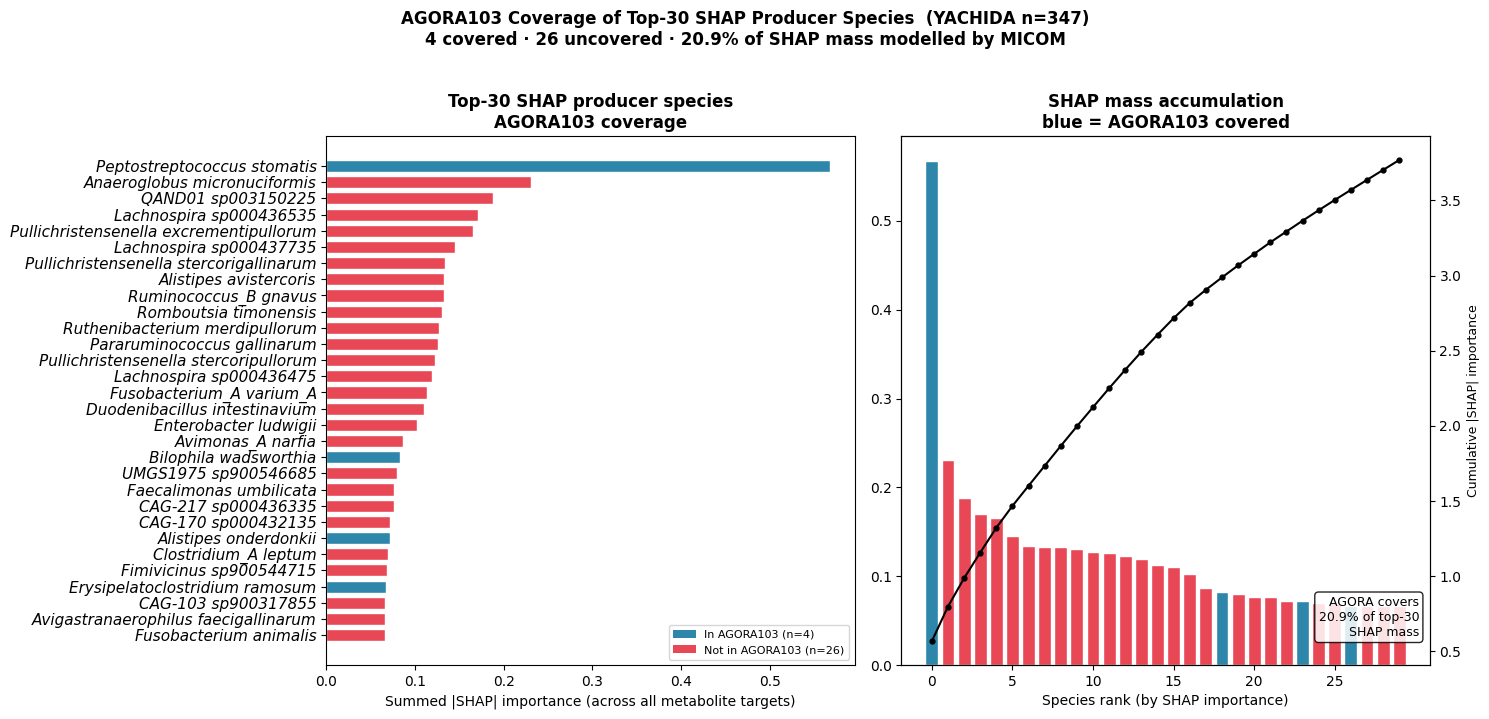

Saved: nb09_shap_agora_coverage.png  +  nb09_shap_agora_coverage.pdf
Saved: nb09_shap_agora_coverage.csv


In [16]:
# ── Step 6c · SHAP-weighted AGORA103 coverage ─────────────────────────────
# Cross-references the top-N SHAP producer species against AGORA103 matched
# species and reports what fraction of cumulative SHAP importance mass is
# covered vs uncovered by the metabolic reconstruction database.
# Standalone: loads shap_producer_candidates.csv; uses agora_pairs from Cell 6
# (or reconstructs from the extracted AGORA manifest on disk as fallback).

import re
from pathlib import Path
import matplotlib.pyplot as plt

# 1 · Load SHAP producer candidates ──────────────────────────────────────────────
shap_cov = pd.read_csv(TABLE_DIR / "shap_producer_candidates.csv")
shap_cov["genus"]   = shap_cov["species"].str.split().str[0]
shap_cov["epithet"] = shap_cov["species"].str.split().str[-1]

# Aggregate total SHAP mass per species across all metabolite targets
shap_per_species = (
    shap_cov.groupby(["species", "genus", "epithet"])["shap_importance"]
    .sum()
    .reset_index()
    .sort_values("shap_importance", ascending=False)
    .reset_index(drop=True)
)

N_TOP = 30
top_sp = shap_per_species.head(N_TOP).copy()

# 2 · Reconstruct AGORA (genus, epithet) pairs ──────────────────────────────────────────
# Prefer variable from Cell 6; fall back to scanning extracted manifest on disk
_agora_pairs = None
if "agora_pairs" in dir():
    _agora_pairs = agora_pairs
    print(f"Using agora_pairs from Cell 6  ({len(_agora_pairs)} species)")
else:
    _base = DATA_DIR / "micom" / "agora_extracted"
    for _p in sorted(Path(_base).rglob("*.csv")):
        try:
            _df = pd.read_csv(_p)
            if {"genus", "species"}.issubset(_df.columns):
                _agora_pairs = set(zip(_df["genus"].str.strip(), _df["species"].str.strip()))
                print(f"Loaded AGORA manifest from {_p.name}  ({len(_agora_pairs)} species)")
                break
        except Exception:
            continue

if _agora_pairs is None:
    raise RuntimeError("Cannot find agora_pairs — run Cell 6 first or check AGORA manifest path")

# 3 · Match SHAP species to AGORA ─────────────────────────────────────────────────────
_MAG_PATTERN = re.compile(r"^sp\d{6,}")  # sp000XXXXX / sp900XXXXX = uncultured MAG

def _agora_match(genus: str, epithet: str, pairs: set) -> bool:
    if _MAG_PATTERN.match(str(epithet)):
        return False
    if (genus, epithet) in pairs:
        return True
    genus_clean = re.sub(r"_[A-Z]+$", "", str(genus))
    return (genus_clean, epithet) in pairs

top_sp["in_agora"] = top_sp.apply(
    lambda r: _agora_match(r["genus"], r["epithet"], _agora_pairs), axis=1
)

# 4 · Summary statistics ────────────────────────────────────────────────────────────────
total_mass     = top_sp["shap_importance"].sum()
covered_mass   = top_sp.loc[top_sp["in_agora"],  "shap_importance"].sum()
uncovered_mass = top_sp.loc[~top_sp["in_agora"], "shap_importance"].sum()
pct_covered    = covered_mass  / total_mass * 100
n_covered      = int(top_sp["in_agora"].sum())
n_uncovered    = int((~top_sp["in_agora"]).sum())

print(f"\nTop-{N_TOP} SHAP species \u2014 AGORA103 coverage")
print(f"  Covered   : {n_covered:>3} species  SHAP mass = {covered_mass:.4f}  ({pct_covered:.1f}%)")
print(f"  Uncovered : {n_uncovered:>3} species  SHAP mass = {uncovered_mass:.4f}  ({100 - pct_covered:.1f}%)")
print(f"\nUncovered species (sorted by SHAP importance):")
print(top_sp.loc[~top_sp["in_agora"], ["species", "shap_importance"]].to_string(index=False))

# 5 · Figure ──────────────────────────────────────────────────────────────────────────────
_BLUE, _RED = "#2E86AB", "#E84855"
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left panel: ranked horizontal bar
_colors = top_sp["in_agora"].map({True: _BLUE, False: _RED})
_ypos   = np.arange(N_TOP)
axes[0].barh(_ypos, top_sp["shap_importance"], color=_colors, edgecolor="white", height=0.75)
axes[0].set_yticks(_ypos)
axes[0].set_yticklabels(top_sp["species"], fontsize=11, style="italic")
axes[0].invert_yaxis()
axes[0].set_xlabel("Summed |SHAP| importance (across all metabolite targets)")
axes[0].set_title(f"Top-{N_TOP} SHAP producer species\nAGORA103 coverage", fontweight="bold")
from matplotlib.patches import Patch as _Patch
axes[0].legend(
    handles=[
        _Patch(facecolor=_BLUE, label=f"In AGORA103 (n={n_covered})"),
        _Patch(facecolor=_RED,  label=f"Not in AGORA103 (n={n_uncovered})"),
    ],
    fontsize=8, loc="lower right"
)

# Right panel: cumulative SHAP mass
_sorted = top_sp.sort_values("shap_importance", ascending=False).reset_index(drop=True)
_bar_c  = _sorted["in_agora"].map({True: _BLUE, False: _RED})
_xpos   = np.arange(N_TOP)
axes[1].bar(_xpos, _sorted["shap_importance"], color=_bar_c, edgecolor="white")
_ax2 = axes[1].twinx()
_ax2.plot(_xpos, _sorted["shap_importance"].cumsum(), "k-o", markersize=3.5, linewidth=1.5)
_ax2.set_ylabel("Cumulative |SHAP| importance", fontsize=9)
axes[1].set_xlabel("Species rank (by SHAP importance)")
axes[1].set_title("SHAP mass accumulation\nblue = AGORA103 covered", fontweight="bold")
axes[1].set_xticks(range(0, N_TOP, 5))
_ax2.text(
    0.98, 0.05,
    f"AGORA covers\n{pct_covered:.1f}% of top-{N_TOP}\nSHAP mass",
    transform=_ax2.transAxes, ha="right", va="bottom", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85)
)

plt.suptitle(
    f"AGORA103 Coverage of Top-{N_TOP} SHAP Producer Species  (YACHIDA n=347)\n"
    f"{n_covered} covered \u00b7 {n_uncovered} uncovered \u00b7 "
    f"{pct_covered:.1f}% of SHAP mass modelled by MICOM",
    fontweight="bold", y=1.02
)
plt.tight_layout()

# --- NEW: Save as both PNG and PDF ---
_out_dir = FIG_DIR / "micom"
_out_dir.mkdir(parents=True, exist_ok=True)

_out_png = _out_dir / "nb09_shap_agora_coverage.png"
_out_pdf = _out_dir / "nb09_shap_agora_coverage.pdf"

fig.savefig(_out_png, dpi=150, bbox_inches="tight")
fig.savefig(_out_pdf, bbox_inches="tight")
plt.show()

# 6 · Save table ─────────────────────────────────────────────────────────────────────────
(
    top_sp[["species", "genus", "epithet", "shap_importance", "in_agora"]]
    .merge(
        shap_cov[["species", "pathway"]].drop_duplicates("species"),
        on="species", how="left"
    )
    .to_csv(TABLE_DIR / "nb09_shap_agora_coverage.csv", index=False)
)
print(f"Saved: {_out_png.name}  +  {_out_pdf.name}")
print("Saved: nb09_shap_agora_coverage.csv")

## Step 6b — Stage-Stratified DA × MICOM Enrichment

Cross-references MICOM mechanistic producers with species that are **differentially
abundant** in early or advanced CRC (from NB02). Unlike SHAP predictors (GTDB genome bins),
DA species are typically named, cultured bacteria — making them far more likely to appear
in the AGORA103 model database.

- `★E` — species is also DA-significant in **Early CRC** (Healthy vs Early, p < 0.05)
- `★A` — species is also DA-significant in **Advanced CRC** (Healthy vs Advanced, p < 0.05)

**Threshold note:** NB02 now runs DA over all 4392 QC-filtered species (previously 500+).
BH correction over 4392 tests at n=57 CRC samples yields approximately zero q<0.05 hits
(expected FP under BH ≈ 4392 × 0.05 ≈ 220 raw positives → virtually no BH survivors).
Uncorrected p < 0.05 is therefore retained as a **sensitivity screen** — not confirmatory.
Stars in the visualisation identify mechanistic-statistical co-occurrence candidates;
confirmatory trinity evidence comes from the genus-anchored pathway in Step 6a.


In [17]:
# ── DA × MICOM intersection ───────────────────────────────────────────────────────
# Load differential abundance species from NB02 and flag MICOM producers that
# are also DA-significant in early or advanced CRC.
# Unlike SHAP (GTDB genome bins), DA species are named cultured bacteria →
# more likely to have AGORA103 models → real mechanistic + clinical overlap.

# BH over 4392 species at n=57 samples yields ~0 hits at q<0.05
# (expected FP ≈ 4392 × 0.05 ≈ 220 raw positives → virtually none survive BH).
# p < 0.05 used as sensitivity screen only; trinity confirmation is via Step 6a.
DA_PVAL = 0.05

da_early_path = TABLE_DIR / "da_species_Healthy_vs_Early_CRC.csv"
da_adv_path   = TABLE_DIR / "da_species_Healthy_vs_Advanced_CRC.csv"

_da_flags_ready = False

if da_early_path.exists() and da_adv_path.exists() and not trinity_df.empty:
    da_early_df = pd.read_csv(da_early_path)
    da_adv_df   = pd.read_csv(da_adv_path)

    da_early_df["epithet"] = da_early_df["feature"].str.split().str[-1]
    da_adv_df["epithet"]   = da_adv_df["feature"].str.split().str[-1]

    # C2 FIX: only enriched species (log2FC > 0) support the MICOM production
    # hypothesis. A depleted species flagged as da_early/da_adv=True would falsely
    # imply the Cell 24 stars support production — this filter corrects that.
    da_early_sig = set(da_early_df.loc[
        (da_early_df["pval"] < DA_PVAL) & (da_early_df["log2FC"] > 0), "epithet"
    ])
    da_adv_sig   = set(da_adv_df.loc[
        (da_adv_df["pval"] < DA_PVAL) & (da_adv_df["log2FC"] > 0), "epithet"
    ])

    print(f"DA Early CRC significant species (p<{DA_PVAL}): {len(da_early_sig)}")
    if da_early_sig:
        print(f"  Examples: {sorted(da_early_sig)[:5]}")
    print(f"DA Advanced CRC significant species (p<{DA_PVAL}): {len(da_adv_sig)}")
    if da_adv_sig:
        print(f"  Examples: {sorted(da_adv_sig)[:5]}")

    # Flag trinity_df (drives Cell 19 visualisation)
    trinity_df["da_early"] = trinity_df["epithet"].isin(da_early_sig)
    trinity_df["da_adv"]   = trinity_df["epithet"].isin(da_adv_sig)

    # Flag flux_summary (for the saved CSV)
    flux_summary["da_early"] = flux_summary["taxon"].isin(da_early_sig)
    flux_summary["da_adv"]   = flux_summary["taxon"].isin(da_adv_sig)

    # Save DA × MICOM overlap table (now includes stage column)
    da_micom_overlap = flux_summary[
        flux_summary["da_early"] | flux_summary["da_adv"]
    ].copy()
    da_micom_overlap.to_csv(TABLE_DIR / "micom_da_overlap_staged.csv", index=False)
    print(f"\nDA × MICOM overlap: {len(da_micom_overlap)} rows, "
          f"{da_micom_overlap['met_name'].nunique()} metabolites, "
          f"{da_micom_overlap['taxon'].nunique()} species")

    if len(da_micom_overlap):
        print("\nMechanistic producers confirmed by CRC differential abundance (top 20):")
        print(da_micom_overlap[
            ["met_name", "taxon_full", "stage", "mean_flux", "pathway", "da_early", "da_adv"]
        ].sort_values("mean_flux", ascending=False).head(20).to_string(index=False))
    else:
        print(f"\nNo DA × MICOM overlap found at p < {DA_PVAL}.")

    _da_flags_ready = True

else:
    reason = []
    if not da_early_path.exists(): reason.append(f"missing {da_early_path.name}")
    if not da_adv_path.exists():   reason.append(f"missing {da_adv_path.name}")
    if trinity_df.empty:           reason.append("trinity_df is empty (run NB03 first to generate SHAP data)")
    print("DA enrichment skipped:", "; ".join(reason) or "unknown reason")
    print("Run NB02 to generate DA results, then re-run this cell.")

# Ensure columns exist so Cell 19 plotting is safe regardless of DA availability
if not _da_flags_ready and not trinity_df.empty:
    trinity_df["da_early"] = False
    trinity_df["da_adv"]   = False

DA Early CRC significant species (p<0.05): 216
  Examples: ['acidifaciens', 'aerofaciens_W', 'arabinoxylanisolvens', 'asparagiformis', 'avicola']
DA Advanced CRC significant species (p<0.05): 202
  Examples: ['acidifaciens', 'aerofaciens_F', 'aerofaciens_L', 'aerofaciens_M', 'aerofaciens_P']

DA × MICOM overlap: 1175 rows, 100 metabolites, 24 species

Mechanistic producers confirmed by CRC differential abundance (top 20):
            met_name                  taxon_full        stage  mean_flux    pathway  da_early  da_adv
            12dhchol       Holdemania filiformis    Early_CRC  79.519923      Other     False    True
           Glutamate Parabacteroides goldsteinii      Healthy  78.366927 Amino Acid      True   False
             Glycine                     pallens      Healthy  77.864790 Amino Acid     False    True
             Ethanol         Gemella morbillorum      Healthy  77.777778      Other     False    True
             Glycine                     pallens    Early_CRC  7

## Step 7 — Visualisation: Dual-Evidence Plot (MICOM flux | SHAP importance)

For each shared metabolite, shows the top-5 mechanistic producers (MICOM, blue) alongside
the top-5 statistical predictors (SHAP, orange) as complementary lines of evidence.
Species confirmed by both are highlighted in green (expected to be rare given AGORA103 vs GTDB gap).

In [18]:
if not trinity_df.empty:
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    mets_to_plot = trinity_df["metabolite"].dropna().unique().tolist()
    # Sort by total MICOM producer count across all stages; cap at 12
    mets_to_plot = sorted(
        mets_to_plot,
        key=lambda m: trinity_df[
            (trinity_df["metabolite"] == m) & trinity_df["mean_flux"].notna()
        ].shape[0],
        reverse=True,
    )[:12]

    n_rows = len(mets_to_plot)
    TOP_N   = 5
    MAX_LBL = 22    # truncate long SHAP species names

    # Stage colors matching utils.PALETTE_3GROUP
    COL_H    = "#4CAF50"    # Healthy   — green
    COL_E    = "#FFC107"    # Early_CRC — amber
    COL_A    = "#F44336"    # Advanced_CRC — red
    COL_SHAP = "#E65100"    # SHAP statistical predictors — orange
    COL_BOTH = "#2E7D32"    # genus-confirmed Trinity — dark green
    STAGE_COLS = {"Healthy": COL_H, "Early_CRC": COL_E, "Advanced_CRC": COL_A}
    STAGES = ["Healthy", "Early_CRC", "Advanced_CRC"]

    fig, axes = plt.subplots(
        n_rows, 4,
        figsize=(22, max(5, 3.5 * n_rows)),
        gridspec_kw={"wspace": 0.20, "hspace": 0.55},
    )
    if n_rows == 1:
        axes = axes.reshape(1, 4)

    for row_idx, met in enumerate(mets_to_plot):
        sub = trinity_df[trinity_df["metabolite"] == met]

        # Genera confirmed at genus level for this metabolite (across all stages)
        confirmed_genera = (
            set(sub.loc[sub["genus_confirmed"] == True, "genus_micom"].dropna()) |
            set(sub.loc[sub["genus_confirmed"] == True, "genus_shap"].dropna())
        )

        # ── Track max flux across all three stages for shared x-axis ────────────
        stage_max_flux = 0.0

        # ── MICOM panels (cols 0, 1, 2) — one per stage ─────────────────────────
        for col_idx, stage in enumerate(STAGES):
            ax = axes[row_idx][col_idx]
            col_color = STAGE_COLS[stage]
            sub_stage = sub[sub["stage"] == stage]
            micom_sub = sub_stage[sub_stage["mean_flux"].notna()].nlargest(TOP_N, "mean_flux")

            if len(micom_sub):
                labels = []
                for _, r in micom_sub.iterrows():
                    name = str(r.get("taxon_full") or r.get("epithet") or "").split()[0]
                    if r.get("da_early", False):
                        name += " \u2605E"
                    elif r.get("da_adv", False):
                        name += " \u2605A"
                    labels.append(name)
                colors = [
                    COL_BOTH if r.get("genus_micom") in confirmed_genera else col_color
                    for _, r in micom_sub.iterrows()
                ]
                ax.barh(range(len(micom_sub)), micom_sub["mean_flux"].values,
                        color=colors, edgecolor="white", height=0.65)
                ax.set_yticks(range(len(micom_sub)))
                ax.set_yticklabels(labels, fontsize=7)
                stage_max_flux = max(stage_max_flux, micom_sub["mean_flux"].max())
            else:
                ax.set_yticks([])
                ax.text(0.5, 0.5, "no data", transform=ax.transAxes,
                        ha="center", va="center", fontsize=7, color="grey")

            ax.invert_xaxis()
            ax.invert_yaxis()
            ax.set_xlabel("MICOM flux\n(mmol/gDW/h)", fontsize=6.5, color=col_color)
            ax.tick_params(axis="x", labelsize=6)
            ax.spines[["top", "right"]].set_visible(False)

        # Enforce shared x-axis scale across the 3 MICOM panels
        if stage_max_flux > 0:
            for col_idx in range(3):
                axes[row_idx][col_idx].set_xlim(right=0, left=stage_max_flux * 1.10)

        # ── SHAP panel (col 3) — stage-independent ─────────────────────────────
        ax_s = axes[row_idx][3]
        # SHAP values are stage-independent (NB03 trained on all samples).
        # trinity_df has one SHAP row per stage per species — deduplicate to one row
        # per species. keep="first" is deterministic and safe since mean_shap is
        # identical across stage copies of the same (epithet, metabolite) pair.
        shap_rows = sub[sub["mean_shap"].notna()]
        shap_sub2 = (
            shap_rows
            .drop_duplicates(subset=["epithet", "metabolite"], keep="first")
            .nlargest(TOP_N, "mean_shap")
        )
        if len(shap_sub2):
            labels_s = []
            for _, r in shap_sub2.iterrows():
                full = " ".join(str(r.get("species") or r.get("epithet") or "").split()[:2])
                if len(full) > MAX_LBL:
                    full = full[:MAX_LBL - 1] + "\u2026"
                labels_s.append(full)
            colors_s = [
                COL_BOTH if r.get("genus_shap") in confirmed_genera else COL_SHAP
                for _, r in shap_sub2.iterrows()
            ]
            ax_s.barh(range(len(shap_sub2)), shap_sub2["mean_shap"].values,
                      color=colors_s, edgecolor="white", height=0.65)
            ax_s.set_yticks(range(len(shap_sub2)))
            ax_s.set_yticklabels(labels_s, fontsize=7)
            ax_s.invert_yaxis()
        ax_s.set_xlabel("Mean |SHAP|\n(NB03, all stages)", fontsize=6.5, color=COL_SHAP)
        ax_s.tick_params(axis="x", labelsize=6)
        ax_s.yaxis.set_ticks_position("right")
        ax_s.yaxis.set_label_position("right")
        ax_s.spines[["top", "left"]].set_visible(False)

    # ── Finalise layout before computing axes positions ──────────────────────────
    fig.subplots_adjust(top=0.93, bottom=0.07, left=0.05, right=0.97)

    # ── Column headers above first row (one per panel) ───────────────────────────
    stage_labels = ["Healthy (MICOM)", "Early CRC (MICOM)", "Advanced CRC (MICOM)",
                    "SHAP predictors"]
    stage_colors = [COL_H, COL_E, COL_A, COL_SHAP]
    for ci, (lbl, clr) in enumerate(zip(stage_labels, stage_colors)):
        pos = axes[0][ci].get_position()
        fig.text((pos.x0 + pos.x1) / 2, pos.y1 + 0.018,
                 lbl, ha="center", va="bottom", fontsize=8, color=clr)

    # ── Metabolite names: centered above all 4 panels ────────────────────────────
    for row_idx, met in enumerate(mets_to_plot):
        pos_l = axes[row_idx][0].get_position()    # leftmost (Healthy) panel
        pos_r = axes[row_idx][3].get_position()    # rightmost (SHAP) panel
        center_x = (pos_l.x0 + pos_r.x1) / 2
        label_y  = pos_l.y1 + 0.006
        fig.text(center_x, label_y, met,
                 ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#222222")

    # ── Legend ───────────────────────────────────────────────────────────────────
    legend_elements = [
        Patch(facecolor=COL_H,    label="MICOM Healthy"),
        Patch(facecolor=COL_E,    label="MICOM Early CRC"),
        Patch(facecolor=COL_A,    label="MICOM Advanced CRC"),
        Patch(facecolor=COL_SHAP, label="SHAP: statistical predictor"),
        Patch(facecolor=COL_BOTH, label="Confirmed at genus level (Trinity)"),
        Line2D([0], [0], linewidth=0, marker="",
               label="\u2605E / \u2605A = also DA in Early / Advanced CRC",
               color="black"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=3,
               fontsize=8, bbox_to_anchor=(0.5, 0.0), frameon=False)

    fig.suptitle(
        "Holy Trinity: Mechanistic Producers (MICOM) vs Statistical Predictors (SHAP)\n"
        "Stage-stratified MICOM flux \u2014 Healthy | Early CRC | Advanced CRC \u2014 Western Diet",
        fontweight="bold", fontsize=10, y=0.995,
    )
    savefig(fig, "micom", "nb09_micom_shap_trinity_staged.png")
else:
    print("No cross-reference data to plot. Run Steps 5\u20136 first.")

Saved figure: E:\D.Ani\Academic\KI\Results\figures\micom\nb09_micom_shap_trinity_staged.pdf


## Step 8 — Community Excretion Heatmap Atlas

Three complementary heatmaps built from the MICOM `grow()` exchange fluxes:

| Figure | Shape | What it shows |
|---|---|---|
| **A** | Sample × Metabolite clustermap | Community metabolic output per sample; rows stage-ordered, cols clustered by co-excretion |
| **B** | Stage × Metabolite summary | Absolute log-flux (top) + Z-score per metabolite (bottom) — highlights stage-specific shifts |
| **C** | Species × Metabolite producer map | Top-30 AGORA species vs all metabolites — who produces what |

**Interpretation note:** `strategy="none"` flux values are LP-feasible but not unique. Treat as presence/absence + relative magnitude, not absolute rates.

In [19]:
# ── Step 8 — Community Excretion Heatmap Atlas ──────────────────────────────────
# Figure A: Sample × Metabolite clustermap  (347 samples × all metabolites)
#            Community flux = Σ species excretion per (sample, metabolite)
#            Rows: stage-ordered, not clustered | Cols: clustered by co-excretion
# Figure B: Stage × Metabolite summary (absolute log-flux + Z-score per metabolite)
# Figure C: Species × Metabolite producer heatmap (top-30 AGORA species)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from utils import savefig

sns.set_style("white")
plt.rcParams.update({"font.family": "DejaVu Sans"})

if "prod_fluxes" not in dir() or prod_fluxes is None or len(prod_fluxes) == 0:
    raise RuntimeError("prod_fluxes not available — run Code Cell 8 (nb cell 14) first.")

# ─────────────────────────────────────────────────────────────────────────────────
# 1. Build sample × metabolite community-level matrix
# ─────────────────────────────────────────────────────────────────────────────────
samp_met = (
    prod_fluxes
    .groupby(["sample_id", "met_name"])["flux"]
    .sum()
    .unstack(fill_value=0.0)
)
samp_met.index = samp_met.index.astype(str)

# Prevalence filter: keep metabolites present in ≥10% of samples
_min_prev = max(1, int(0.10 * len(samp_met)))
_met_prev = (samp_met > 0).sum(axis=0)
samp_met  = samp_met.loc[:, _met_prev >= _min_prev]
n_samp, n_met = samp_met.shape
print(f"Community excretion matrix: {n_samp} samples × {n_met} metabolites "
      f"(≥10% prevalence; {(_met_prev < _min_prev).sum()} excluded)")

# ─────────────────────────────────────────────────────────────────────────────────
# 2. Stage ordering and row color bar
# ─────────────────────────────────────────────────────────────────────────────────
_STAGE_ORDER  = ["Healthy", "Early_CRC", "Advanced_CRC"]
_STAGE_COLORS = {"Healthy": "#4CAF50", "Early_CRC": "#FFC107", "Advanced_CRC": "#F44336"}

_stage_lookup = pd.Series({str(k): v for k, v in meta["Stage.3Group"].to_dict().items()})
_stage_ser    = _stage_lookup.reindex(samp_met.index).fillna("Unknown")

_stage_codes = pd.Categorical(
    _stage_ser, categories=_STAGE_ORDER + ["Unknown"], ordered=True
).codes
_sort_idx    = np.argsort(_stage_codes, kind="stable")
_samp_met_s  = samp_met.iloc[_sort_idx].copy()
_stage_s     = _stage_ser.iloc[_sort_idx]

_row_colors = _stage_s.map(_STAGE_COLORS).fillna("#BBBBBB").rename("Stage")

# ─────────────────────────────────────────────────────────────────────────────────
# 3. Metabolite pathway color bar
# ─────────────────────────────────────────────────────────────────────────────────
_met_pw = (
    prod_fluxes[["met_name", "pathway"]]
    .drop_duplicates("met_name")
    .set_index("met_name")["pathway"]
)
_PATHWAY_COLORS = {
    "Polyamine":            "#9C27B0",
    "SCFA":                 "#2196F3",
    "Amino Acid":           "#FF9800",
    "Indole / Tryptophan":  "#009688",
    "Nucleoside":           "#795548",
    "Bile Acid":            "#607D8B",
    "Sugar / Carbohydrate": "#66BB6A",
    "Vitamin":              "#FF80AB",
    "Ion":                  "#90CAF9",
    "Other":                "#EEEEEE",
}
_col_colors_df = pd.DataFrame(
    {"Pathway": _samp_met_s.columns.map(
        lambda m: _PATHWAY_COLORS.get(_met_pw.get(m, "Other"), "#EEEEEE")
    )},
    index=_samp_met_s.columns
)

# ─────────────────────────────────────────────────────────────────────────────────
# 4. DA annotation (optional — requires da-micom-code to have run)
# ─────────────────────────────────────────────────────────────────────────────────
_da_met_early = set()
_da_met_adv   = set()
if ("_da_flags_ready" in dir()) and _da_flags_ready and "da_early" in flux_summary.columns:
    for _m in _samp_met_s.columns:
        _fsub = flux_summary[flux_summary["met_name"] == _m]
        if _fsub["da_early"].any(): _da_met_early.add(_m)
        if _fsub["da_adv"].any():   _da_met_adv.add(_m)
    print(f"DA-flagged metabolites: {len(_da_met_early)} (Early CRC), "
          f"{len(_da_met_adv)} (Advanced CRC)")

# ─────────────────────────────────────────────────────────────────────────────────
# 5. log1p transform
# ─────────────────────────────────────────────────────────────────────────────────
_mat = np.log1p(_samp_met_s)

# ═════════════════════════════════════════════════════════════════════════════════
# FIGURE A — Sample × Metabolite clustermap
# ═════════════════════════════════════════════════════════════════════════════════
_fig_w = max(22, n_met * 0.27)
_fig_h = 18

_cg = sns.clustermap(
    _mat,
    row_cluster=False,           # keep stage order; rows not clustered
    col_cluster=True,            # cluster metabolites by co-excretion
    row_colors=_row_colors,
    col_colors=_col_colors_df,
    cmap="YlOrRd",
    xticklabels=True,
    yticklabels=False,
    linewidths=0,
    figsize=(_fig_w, _fig_h),
    dendrogram_ratio=(0.01, 0.12),
    colors_ratio=(0.012, 0.012),
    cbar_pos=(0.01, 0.87, 0.013, 0.07),
    cbar_kws={"label": "log(1 + flux sum)"},
    vmin=0,
)

# Annotate DA-flagged metabolites on x-axis labels
_xtick_labels = []
for _t in _cg.ax_heatmap.get_xticklabels():
    _txt = _t.get_text()
    _sfx = ("★E" if _txt in _da_met_early else "") + ("★A" if _txt in _da_met_adv else "")
    _xtick_labels.append(_txt + ("  " + _sfx if _sfx else ""))
_cg.ax_heatmap.set_xticklabels(_xtick_labels, rotation=90, fontsize=6.0, ha="right")
_cg.ax_heatmap.set_xlabel("Metabolite (clustered by co-excretion pattern)", fontsize=9)
_cg.ax_heatmap.set_ylabel(f"Samples (n={n_samp}, ordered by stage →)", fontsize=9)

# Stage + pathway legends
_stage_patches = [mpatches.Patch(color=c, label=s) for s, c in _STAGE_COLORS.items()]
_pw_present    = set(_met_pw.reindex(_samp_met_s.columns).dropna().unique())
_pw_patches    = [
    mpatches.Patch(color=c, label=p)
    for p, c in _PATHWAY_COLORS.items()
    if p in _pw_present and p != "Other"
]
_leg1 = _cg.fig.legend(
    handles=_stage_patches, title="CRC Stage",
    loc="lower left", bbox_to_anchor=(0.01, 0.01),
    fontsize=8, title_fontsize=9, frameon=True, borderpad=0.8
)
_cg.fig.legend(
    handles=_pw_patches, title="Metabolite Pathway",
    loc="lower center", bbox_to_anchor=(0.50, 0.01),
    fontsize=7, title_fontsize=8.5, frameon=True, ncol=3
)
_cg.fig.add_artist(_leg1)

_cg.fig.suptitle(
    "MICOM Community Excretion Atlas — All Samples × All Metabolites (Western Diet)\n"
    "Community flux = Σ species excretion | Rows: stage-ordered | Cols: co-excretion clustered\n"
    "★E = DA-significant producer in Early CRC   ★A = DA-significant producer in Advanced CRC",
    fontsize=9, fontweight="bold", y=1.005
)
savefig(_cg.fig, "micom", "nb09_heatmap_sample_metabolite.png")
print(f"Fig A saved: nb09_heatmap_sample_metabolite.png  [{_fig_w:.0f}×{_fig_h} in]")
plt.close(_cg.fig)

# Store clustered column order for use in Figs B and C
if hasattr(_cg, "dendrogram_col") and _cg.dendrogram_col is not None:
    _col_order = _samp_met_s.columns[_cg.dendrogram_col.reordered_ind]
else:
    _col_order = _samp_met_s.columns   # fallback: original order

# ═════════════════════════════════════════════════════════════════════════════════
# FIGURE B — Stage × Metabolite summary (absolute log-flux + Z-score)
# ═════════════════════════════════════════════════════════════════════════════════
_tmp_df = _samp_met_s.copy()
_tmp_df["_stage"] = _stage_s.values
_present_stages = [s for s in _STAGE_ORDER if s in _stage_s.values]
_stage_met = (
    _tmp_df
    .groupby("_stage")[list(_samp_met_s.columns)]
    .mean()
    .reindex(_present_stages)
)[_col_order]

# Z-score per metabolite (column-wise) — highlights relative stage changes
_stage_std = _stage_met.std(axis=0).replace(0, 1)
_stage_z   = (_stage_met - _stage_met.mean(axis=0)) / _stage_std

_fig2, (_ax_abs, _ax_z) = plt.subplots(
    2, 1,
    figsize=(max(20, n_met * 0.27), 6),
    gridspec_kw={"hspace": 0.55}
)
# Top panel: absolute log-flux per stage
sns.heatmap(
    np.log1p(_stage_met), ax=_ax_abs, cmap="YlOrRd",
    linewidths=0.3, linecolor="#E0E0E0",
    xticklabels=False, yticklabels=True, vmin=0,
    cbar_kws={"label": "log(1 + mean flux)", "shrink": 0.55}
)
_ax_abs.set_title("Mean community excretion flux per CRC stage (log scale)", fontsize=9, fontweight="bold")
_ax_abs.set_ylabel("Stage", fontsize=9)
_ax_abs.set_yticklabels(_ax_abs.get_yticklabels(), fontsize=9, rotation=0)

# Bottom panel: Z-scored per metabolite
sns.heatmap(
    _stage_z, ax=_ax_z, cmap="RdBu_r", center=0,
    linewidths=0.3, linecolor="#E0E0E0",
    xticklabels=True, yticklabels=True, vmin=-2.5, vmax=2.5,
    cbar_kws={"label": "Z-score (per metabolite)", "shrink": 0.55}
)
_ax_z.set_xticklabels(_ax_z.get_xticklabels(), rotation=90, fontsize=5.5, ha="right")
_ax_z.set_title(
    "Z-scored excretion per metabolite — positive = elevated in that stage "
    "(same column order as atlas above)", fontsize=9, fontweight="bold"
)
_ax_z.set_ylabel("Stage", fontsize=9)
_ax_z.set_yticklabels(_ax_z.get_yticklabels(), fontsize=9, rotation=0)

_fig2.suptitle("Stage × Metabolite Community Excretion Summary", fontsize=10, fontweight="bold", y=1.02)
savefig(_fig2, "micom", "nb09_heatmap_stage_metabolite.png")
print("Fig B saved: nb09_heatmap_stage_metabolite.png")
plt.close(_fig2)

# ═════════════════════════════════════════════════════════════════════════════════
# FIGURE C — Top-30 Species × All Metabolites producer heatmap
# ═════════════════════════════════════════════════════════════════════════════════
# Top 30 species by summed mean excretion flux across all metabolites and stages
_top_sp = (
    flux_summary
    .groupby("taxon_full")["mean_flux"]
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .index.tolist()
)
_spec_raw = (
    flux_summary[flux_summary["taxon_full"].isin(_top_sp)]
    .groupby(["taxon_full", "met_name"])["mean_flux"]
    .mean()
    .unstack(fill_value=0.0)
)
# Align to Fig A column order; fill metabolites not in flux_summary with 0
_spec_cols = [c for c in _col_order if c in _spec_raw.columns]
_spec_raw  = _spec_raw.reindex(columns=_spec_cols, fill_value=0.0)
# Sort rows (species) by total flux descending
_sp_row_order = _spec_raw.sum(axis=1).sort_values(ascending=False).index
_spec_raw     = _spec_raw.loc[_sp_row_order]

_fig3, _ax3 = plt.subplots(figsize=(max(20, len(_spec_cols) * 0.27), 10))
sns.heatmap(
    np.log1p(_spec_raw),
    ax=_ax3,
    cmap="PuRd",
    linewidths=0,
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"label": "log(1 + mean flux)", "shrink": 0.5}
)
_ax3.set_xticklabels(_ax3.get_xticklabels(), rotation=90, fontsize=6.0, ha="right")
_ax3.set_yticklabels(_ax3.get_yticklabels(), fontsize=7.5, fontstyle="italic", rotation=0)
_ax3.set_xlabel("Metabolite (same column order as atlas)", fontsize=9)
_ax3.set_ylabel("Species (top-30 by total flux)", fontsize=9)
_ax3.set_title(
    "Top-30 Mechanistic Producers × All Metabolites — Mean Excretion Flux (AGORA103, all stages combined)",
    fontsize=10, fontweight="bold"
)
_fig3.tight_layout()
savefig(_fig3, "micom", "nb09_heatmap_species_metabolite.png")
print("Fig C saved: nb09_heatmap_species_metabolite.png")
plt.close(_fig3)

# ─────────────────────────────────────────────────────────────────────────────────
# Summary: most stage-variable metabolites
# ─────────────────────────────────────────────────────────────────────────────────
print(f"\nTop 10 most stage-variable metabolites (std across stage means):")
_met_var = _stage_met.std(axis=0).sort_values(ascending=False).head(10)
for _m, _v in _met_var.items():
    _pw_lbl = _met_pw.get(_m, "?")
    _flag   = ("  ★E" if _m in _da_met_early else "") + ("  ★A" if _m in _da_met_adv else "")
    print(f"  {_m:30s}  [{_pw_lbl:22s}]  stage-std={_v:.2f}{_flag}")


Community excretion matrix: 325 samples × 120 metabolites (≥10% prevalence; 50 excluded)
DA-flagged metabolites: 73 (Early CRC), 79 (Advanced CRC)
Saved figure: E:\D.Ani\Academic\KI\Results\figures\micom\nb09_heatmap_sample_metabolite.pdf
Fig A saved: nb09_heatmap_sample_metabolite.png  [32×18 in]
Saved figure: E:\D.Ani\Academic\KI\Results\figures\micom\nb09_heatmap_stage_metabolite.pdf
Fig B saved: nb09_heatmap_stage_metabolite.png
Saved figure: E:\D.Ani\Academic\KI\Results\figures\micom\nb09_heatmap_species_metabolite.pdf
Fig C saved: nb09_heatmap_species_metabolite.png

Top 10 most stage-variable metabolites (std across stage means):
  Ammonium                        [Other                 ]  stage-std=29.72  ★E  ★A
  Acetate                         [SCFA                  ]  stage-std=18.34  ★E  ★A
  D-Lactate                       [Other                 ]  stage-std=16.44  ★E  ★A
  Phosphate                       [Other                 ]  stage-std=16.28  ★E  ★A
  CO2              